# PGA Tournament Shots Data Analysis

## Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get Data

In [13]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "tournament_shots_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "samanthastaheli/tournamentshots/versions/9",
  file_path,
  pandas_kwargs={"encoding": "latin1"} # European players have different spelling
)

df.head()

/tmp/ipykernel_4562/1572511923.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'tournamentshots' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1,246 yds,166 yds,Right Rough,4,423
1,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,2,163 yds,18 ft 5 in.,Green,4,423
2,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,3,20 ft 8 in.,2 ft 1 in.,Green,4,423
3,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,4,2 ft 1 in.,0,In Hole,4,423
4,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,2,1,234 yds,303 yds,Tree Outline,5,532


### Check Data

In [14]:
# 1. Group by player and tournament, then count UNIQUE rounds and holes
data_check = df.groupby(['tournament_id', 'player']).agg(
    rounds_played=('round', 'nunique'),
    unique_holes_played=('hole', 'nunique')
).reset_index()

# 2. A complete tournament means exactly 4 rounds and 18 unique holes
# Let's flag anyone who doesn't match the 72-hole benchmark
is_complete = (data_check['rounds_played'] == 4) & (data_check['unique_holes_played'] == 18)
missing_data_players = data_check[~is_complete]

# 3. Print the results
if missing_data_players.empty:
    print("All players have complete data (4 rounds, 18 holes each).")
else:
    print(f"Found {len(missing_data_players)} players with missing or incomplete data layers:")
    print(missing_data_players.to_string(index=False))

All players have complete data (4 rounds, 18 holes each).


### Change shotDist and toHole to float datapoints

In [15]:
import re

def parse_golf_distance_to_yards(val):
    # Convert to string and clean up whitespaces
    val = str(val).strip().lower()

    # Handle clean zeros or empty rows
    if val in ['0', '0.0', 'nan', '']:
        return 0.0

    # Check 1: If it's explicitly in yards (e.g., "334 yds")
    if 'yd' in val:
        match = re.search(r'([\d.]+)', val)
        return float(match.group(1)) if match else 0.0

    # Check 2: If it's in feet/inches (e.g., "5 ft 11 in." or "79 ft 5 in.")
    if 'ft' in val or 'in' in val:
        # Extract feet if present
        ft_match = re.search(r'(\d+)\s*ft', val)
        feet = float(ft_match.group(1)) if ft_match else 0.0

        # Extract inches if present
        in_match = re.search(r'(\d+)\s*in', val)
        inches = float(in_match.group(1)) if in_match else 0.0

        # Convert total feet and inches into decimal yards (3 feet in a yard, 36 inches in a yard)
        total_yards = (feet / 3.0) + (inches / 36.0)
        return round(total_yards, 3) # Rounding to 3 decimal places for precision

    # Check 3: Fallback if it's a raw number string without units
    try:
        return float(val)
    except ValueError:
        return 0.0

# Apply the parsing function to both columns
df["shot_dist_yards"] = df["shot_dist"].apply(parse_golf_distance_to_yards)
df["to_hole_yards"] = df["to_hole"].apply(parse_golf_distance_to_yards)

print(df[["shot_dist", "shot_dist_yards", "to_hole", "to_hole_yards"]].head())

     shot_dist  shot_dist_yards      to_hole  to_hole_yards
0      246 yds          246.000      166 yds        166.000
1      163 yds          163.000  18 ft 5 in.          6.139
2  20 ft 8 in.            6.889   2 ft 1 in.          0.694
3   2 ft 1 in.            0.694            0          0.000
4      234 yds          234.000      303 yds        303.000


### Categorize Locations

In [16]:
# Sort chronologically so shifts align perfectly within each hole
df = df.sort_values(by=['tournament_id', 'round', 'hole', 'player_id', 'shot_number']).copy()

# Get the *previous* landing location (where the current shot is being hit from)
df['shot_started_from'] = df.groupby(['tournament_id', 'round', 'hole', 'player_id'])['location'].shift(1)

# For the very first shot of a hole, the previous location is blank (NaN),
# which means they are hitting from the Tee Box.
df['shot_started_from'] = df['shot_started_from'].fillna('tee')

# Track the holed status as an independent variable
df["is_holed"] = df["location"].str.lower().str.contains("in hole", na=False)

In [17]:
def categorize_locations(row):
    start_loc = str(row["shot_started_from"]).lower().strip()
    end_loc = str(row["location"]).lower().strip()

    # Shot 1 on Par 4s/5s is a Drive (On Par 3s, Shot 1 is technically an Approach)
    try:
        shot_num = int(float(row["shot_number"]))
    except (ValueError, TypeError):
        shot_num = None

    # if row["shot_number"] == 1 or str(row["shot_number"]).strip() == "1" or int(float(row["shot_number"])) == 1:
    if shot_num == 1:
        shot_class = "Tee"
        # if row["par"] == 3:
        #     shot_class = "Tee"
        # else:
        #     shot_class = "Tee"
    elif "green" in start_loc:
        shot_class = "Putt"
    else:
        shot_class = "Approach"

    return shot_class

df["shot_type"] = df.apply(categorize_locations, axis=1)

df.head(10)

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type
40935,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee
40936,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach
40937,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt
40938,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee
1,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,2,163 yds,18 ft 5 in.,Green,4,423,163.000,6.139,Right Rough,False,Approach
2,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,3,20 ft 8 in.,2 ft 1 in.,Green,4,423,6.889,0.694,Green,False,Putt
3,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,4,2 ft 1 in.,0,In Hole,4,423,0.694,0.000,Green,True,Putt
309,THE PLAYERS Championship,R2023011,Stewart Cink,20229,1,1,1,280 yds,132 yds,Right Rough,4,423,280.000,132.000,tee,False,Tee
310,THE PLAYERS Championship,R2023011,Stewart Cink,20229,1,1,2,114 yds,62 ft 10 in.,Right Fairway,4,423,114.000,20.944,Right Rough,False,Approach


In [18]:
def categorize_positions(row):
    start_loc = str(row["shot_started_from"]).lower().strip()
    end_loc = str(row["location"]).lower().strip()

    # Shot 1 on Par 4s/5s is a Drive (On Par 3s, Shot 1 is technically an Approach)
    if row["shot_number"] == 1:
        shot_pos = "tee"
    elif "green" in start_loc:
        shot_pos = "putt"
    elif "fairway" in start_loc:
        shot_pos = "fairway"
    elif "rough" in start_loc:
        shot_pos = "rough"
    elif "bunker" in start_loc:
        shot_pos = "sand"
    else:
        shot_pos = "approach"

    return shot_pos

df["shot_pos"] = df.apply(categorize_positions, axis=1)

df.head(10)

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos
40935,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach
40936,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway
40937,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt
40938,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach
1,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,2,163 yds,18 ft 5 in.,Green,4,423,163.000,6.139,Right Rough,False,Approach,rough
2,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,3,20 ft 8 in.,2 ft 1 in.,Green,4,423,6.889,0.694,Green,False,Putt,putt
3,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,4,2 ft 1 in.,0,In Hole,4,423,0.694,0.000,Green,True,Putt,putt
309,THE PLAYERS Championship,R2023011,Stewart Cink,20229,1,1,1,280 yds,132 yds,Right Rough,4,423,280.000,132.000,tee,False,Tee,approach
310,THE PLAYERS Championship,R2023011,Stewart Cink,20229,1,1,2,114 yds,62 ft 10 in.,Right Fairway,4,423,114.000,20.944,Right Rough,False,Approach,rough


### Drop Shot Number Nan

In [19]:
# Force shot_number to be numeric, turning rogue text/strings into NaN safely
df["shot_number"] = pd.to_numeric(df["shot_number"], errors="coerce")

# Drop rows where shot_number became NaN to protect the max calculation
df = df.dropna(subset=["shot_number"])

df.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos
40935,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1.0,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach
40936,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2.0,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway
40937,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3.0,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt
40938,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4.0,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1.0,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach


## Helper Functions

In [20]:
def get_hole_scores(df):
    # Group by player, round, and hole, then find the highest shot number
    shots_per_hole = df.groupby(['tournament_id', 'player', 'round', 'hole'])['shot_number'].max().reset_index()

    # Rename the column to make it clear it represents the hole score
    shots_per_hole.rename(columns={'shot_number': 'total_shots'}, inplace=True)
    return shots_per_hole

def get_total_scores(df):
    hole_scores = get_hole_scores(df)

    # Sum the hole scores to get the total tournament score for each player
    total_scores = hole_scores.groupby(['player', 'tournament_id'])['total_shots'].sum().reset_index()
    total_scores.rename(columns={'total_shots': 'total_strokes'}, inplace=True)

    return total_scores

def get_top_players(df, amount=3):
    total_scores = get_total_scores(df)

    # Sort by strokes ascending (lowest score is best) and grab the top players amount
    top_players = total_scores.sort_values(by='total_strokes', ascending=True).head(amount)

    return top_players

def get_top_players_by_tournament(df, amount=3):
    total_scores = get_total_scores(df)

    return total_scores.groupby('tournament_id').apply(
        lambda x: x.nsmallest(amount, 'total_strokes')
    ).reset_index(drop=True)

## Data Analysis

### Unique Values

In [21]:
tournaments = df['tournament'].unique()
print("Tournaments: ", tournaments)

Tournaments:  ['THE PLAYERS Championship' 'the Memorial Tournament presented by Workday'
 'Cadillac Championship']


In [22]:
tournaments = df['tournament_id'].nunique()
print("Tournaments: ", tournaments)

Tournaments:  6


In [23]:
players = df['player'].nunique()
print("total players: ", players)

total players:  230


In [25]:
players_per_tournament = df.groupby('tournament')['player'].nunique()
print(players_per_tournament)

tournament
Cadillac Championship                            72
THE PLAYERS Championship                        226
the Memorial Tournament presented by Workday     71
Name: player, dtype: int64


In [26]:
players_per_tournament = df.groupby('tournament_id')['player'].nunique()
print(players_per_tournament)

tournament_id
R2023011    141
R2024011    142
R2025011    143
R2025023     71
R2026011    122
R2026556     72
Name: player, dtype: int64


In [27]:
len(df)

200466

In [ ]:
# players = df.groupby('tournament')['player'].unique()
players = df[df['tournament_id'] == 'R2025011']
players = players['player'].unique()
print("players: ", players)

players:  ['Charley Hoffman' 'Justin Rose' 'Matt Kuchar' 'Adam Scott' 'Nick Taylor'
 'Lucas Glover' 'Jhonattan Vegas' 'Luke List' 'David Skinns'
 'Brian Harman' 'Camilo Villegas' 'Rory McIlroy' 'Seamus Power'
 'Nate Lashley' 'Billy Horschel' 'Brice Garnett' 'Tony Finau' 'C.T. Pan'
 'Ryan Fox' 'Henrik Norlander' 'Tommy Fleetwood' 'Chris Kirk'
 'Gary Woodland' 'Emiliano Grillo' 'Rafael Campos' 'Rickie Fowler'
 'Patton Kizzire' 'K.H. Lee' 'Hideki Matsuyama' 'Keegan Bradley'
 'Shane Lowry' 'Adam Hadwin' 'Justin Thomas' 'Thomas Detry'
 'Byeong Hun An' 'Bud Cauley' 'Jordan Spieth' 'Joel Dahmen'
 'Russell Henley' 'Harris English' 'Andrew Putnam' 'Laurie Canter'
 'Peter Malnati' 'Chan Kim' 'Lanto Griffin' 'Patrick Cantlay'
 'Beau Hossler' 'Mackenzie Hughes' 'Tom Hoge' 'Kris Ventura'
 'David Lipsky' 'Patrick Rodgers' 'Stephan Jaeger' 'Mark Hubbard'
 'Ben Kohles' 'Sam Ryder' 'Min Woo Lee' 'Si Woo Kim' 'Alejandro Tosti'
 'J.J. Spaun' 'Ben Silverman' 'Kevin Roy' 'Keith Mitchell' 'Sungjae Im'
 'Mic

In [ ]:
loc = df['location'].unique()
print("loc: ", loc)

loc:  ['Right Fairway Bunker' 'Green' 'In Hole' 'Right Rough' 'Right Fairway'
 'Left Intermediate' 'Tree Outline' 'Front Left Greenside Bunker'
 'Left Fairway' 'Left Greenside Bunker' 'Other' 'Fringe'
 'Left Fairway Bunker' 'Cart Path' 'Right Intermediate' 'Left Rough'
 'Right Greenside Bunker' 'Right Front Greenside Bunker'
 'Left Rear Greenside Bunker' 'Water' 'Fairway' 'Intermediate Rough'
 'Primary Rough' 'Rear Greenside Bunker' 'Drop Zone' 'Unknown' 'Tee Box'
 'Dirt Outline' 'Front Center Greenside Bunker' 'Landscaping' 'Wall'
 'Fairway Bunker' 'Right Rear Greenside Bunker' 'Left Green'
 'Greenside Bunker' 'Right Tree Outline' 'Right Green' 'Left Tree Outline'
 'Left Bunker' 'Right Bunker' 'Left Cart Path' 'Around the Green'
 'Right Water' 'Left Water' 'Right Cart Path' 'Left Dirt Outline'
 'Right Landscaping' 'Left Wall' 'Left Native Area' 'Right Native Area'
 'Native Area' 'Right Dirt Outline' 'Right Wall']


### Total Shots

In [ ]:
shots_per_hole = get_hole_scores(df)

print("Shots per hole for every player:")
print(shots_per_hole.head(20)) # Printing the first 20 rows

Shots per hole for every player:
   tournament_id          player  round  hole  total_shots
0       R2023011  Aaron Baddeley      1     1          4.0
1       R2023011  Aaron Baddeley      1     2          4.0
2       R2023011  Aaron Baddeley      1     3          3.0
3       R2023011  Aaron Baddeley      1     4          3.0
4       R2023011  Aaron Baddeley      1     5          4.0
5       R2023011  Aaron Baddeley      1     6          3.0
6       R2023011  Aaron Baddeley      1     7          4.0
7       R2023011  Aaron Baddeley      1     8          4.0
8       R2023011  Aaron Baddeley      1     9          5.0
9       R2023011  Aaron Baddeley      1    10          4.0
10      R2023011  Aaron Baddeley      1    11          5.0
11      R2023011  Aaron Baddeley      1    12          4.0
12      R2023011  Aaron Baddeley      1    13          3.0
13      R2023011  Aaron Baddeley      1    14          6.0
14      R2023011  Aaron Baddeley      1    15          4.0
15      R2023011  Aaron

In [ ]:
avg_hole_score = shots_per_hole.groupby('hole')['total_shots'].mean().reset_index()
print(avg_hole_score.sort_values(by='total_shots', ascending=False))

    hole  total_shots
10    11     4.721014
8      9     4.588832
1      2     4.545125
17    18     4.343116
15    16     4.330677
13    14     4.230769
4      5     4.214053
6      7     4.194273
9     10     4.172826
0      1     4.134323
5      6     4.076394
14    15     4.025018
11    12     3.938043
3      4     3.937726
16    17     3.356522
7      8     3.343365
2      3     3.280174
12    13     3.213406


In [ ]:
round_scores = shots_per_hole.groupby(['player', 'round'])['total_shots'].sum().reset_index()
print(round_scores)

             player  round  total_shots
0        A.J. Ewart      1         78.0
1        A.J. Ewart      2         75.0
2        A.J. Ewart      3         75.0
3        A.J. Ewart      4         75.0
4    Aaron Baddeley      1        147.0
..              ...    ...          ...
915    Zach Bauchou      4         74.0
916     Zecheng Dou      1         76.0
917     Zecheng Dou      2         74.0
918     Zecheng Dou      3         74.0
919     Zecheng Dou      4         74.0

[920 rows x 3 columns]


### Leaderboard

In [ ]:
total_scores = get_total_scores(df)

# grab the top 3 players
top_players = get_top_players(df, amount=3)

print("--- TOP 3 LEADERBOARD ---")
print(top_players.to_string(index=False))

# Sort by strokes ascending (lowest score is best) and grab the top 9 (3 per tournament)
top_3_per_tournament = total_scores.groupby('tournament_id').apply(
    lambda x: x.nsmallest(3, 'total_strokes')
).reset_index(drop=True)
print("\n--- TOP 3 by TOURNAMENT LEADERBOARD ---")
print(top_3_per_tournament.to_string(index=False))

--- TOP 3 LEADERBOARD ---
       player tournament_id  total_strokes
Cameron Young      R2026556          219.0
  Ben Griffin      R2026556          241.0
  Chez Reavie      R2023011          244.0

--- TOP 3 by TOURNAMENT LEADERBOARD ---
           player tournament_id  total_strokes
      Chez Reavie      R2023011          244.0
Scottie Scheffler      R2023011          267.0
       Chris Kirk      R2023011          270.0
Scottie Scheffler      R2024011          268.0
     Brian Harman      R2024011          269.0
    Wyndham Clark      R2024011          269.0
       Bud Cauley      R2025011          269.0
       J.J. Spaun      R2025011          276.0
     Rory McIlroy      R2025011          276.0
Scottie Scheffler      R2025023          278.0
      Ben Griffin      R2025023          282.0
      Sepp Straka      R2025023          283.0
    Cameron Young      R2026011          275.0
 Matt Fitzpatrick      R2026011          276.0
   Russell Henley      R2026011          277.0
    Camer

/tmp/ipykernel_13020/4148601440.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_3_per_tournament = total_scores.groupby('tournament_id').apply(


## Plot Data

/tmp/ipykernel_13020/3787376815.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return total_scores.groupby('tournament_id').apply(


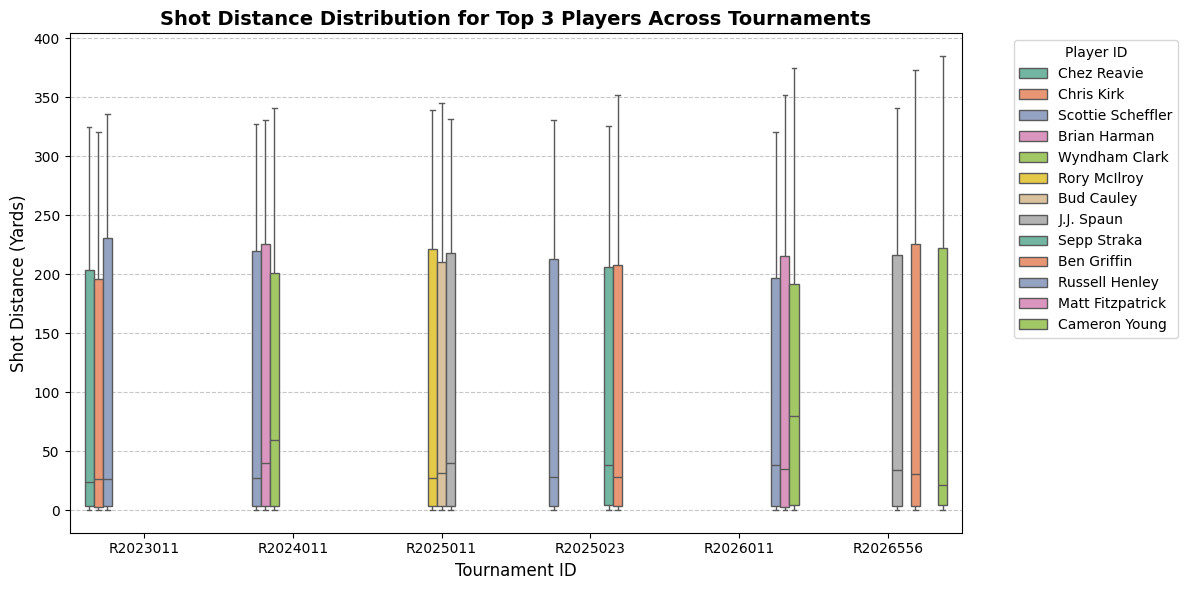

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract just the top 3 players per tournament
top_3_leaderboard = get_top_players_by_tournament(df)

# Create a multi-column index merge to pull only the raw shots belonging to those specific player/tour combos
top_3_shot_data = df.merge(top_3_leaderboard[['tournament_id', 'player']], on=['tournament_id', 'player'], how='inner')

# Plot
plt.figure(figsize=(12, 6))

# Create shot distance distribution
sns.boxplot(
    data=top_3_shot_data,
    x='tournament_id',
    y='shot_dist_yards',
    hue='player',
    palette='Set2'
)

plt.title("Shot Distance Distribution for Top 3 Players Across Tournaments", fontsize=14, fontweight='bold')
plt.xlabel("Tournament ID", fontsize=12)
plt.ylabel("Shot Distance (Yards)", fontsize=12)
plt.legend(title="Player ID", bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Drives

In [ ]:
df.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos
40935,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1.0,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach
40936,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2.0,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway
40937,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3.0,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt
40938,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4.0,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1.0,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach


/tmp/ipykernel_13020/3829203462.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


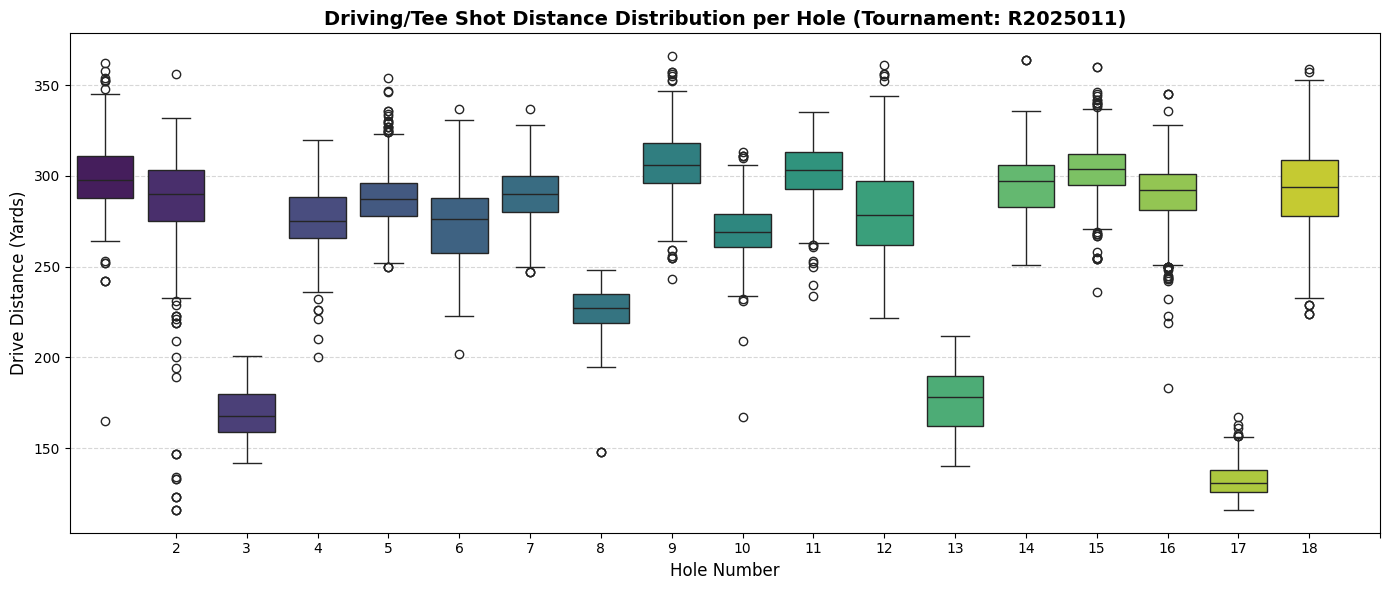

In [ ]:
# Plot drive distances
df_R2025011 = df[df['tournament_id'] == 'R2025011']
drives_R2025011 = df_R2025011[df_R2025011['shot_type'] == 'Tee']

plt.figure(figsize=(14, 6))

# 3. Create a boxplot or violinplot to show driving distance distribution per hole
sns.boxplot(
    data=drives_R2025011,
    x='hole',
    y='shot_dist_yards',
    palette='viridis'
)

# 4. Clean up labels and styling
plt.title("Driving/Tee Shot Distance Distribution per Hole (Tournament: R2025011)", fontsize=14, fontweight='bold')
plt.xlabel("Hole Number", fontsize=12)
plt.ylabel("Drive Distance (Yards)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure hole numbers are ordered sequentially on the X-axis
plt.xticks(sorted(drives_R2025011['hole'].unique()))

plt.tight_layout()
plt.show()

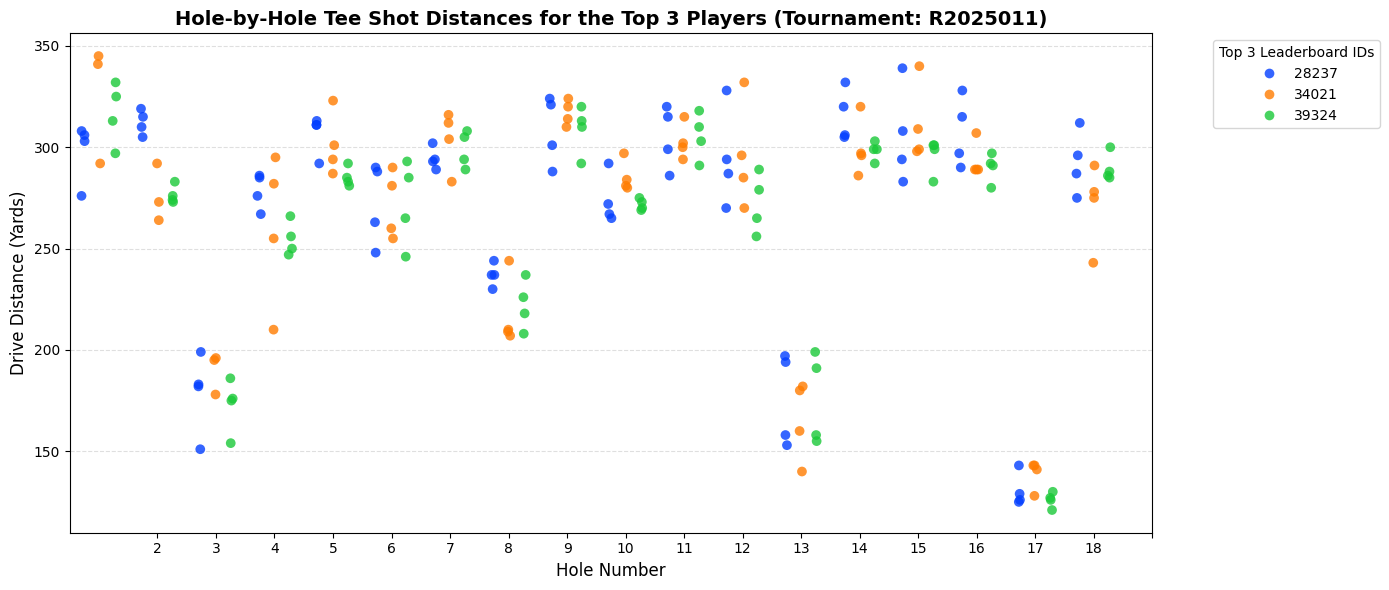

In [ ]:
# Plot top player drive distances
hole_scores = df_R2025011.groupby(['player_id', 'round', 'hole'])['shot_number'].max().reset_index()

# Sum hole scores to get total strokes for the tournament per player
total_scores = hole_scores.groupby('player_id')['shot_number'].sum().reset_index()
total_scores.rename(columns={'shot_number': 'total_strokes'}, inplace=True)

# Grab the 3 players with the absolute lowest strokes
top_3_player_ids = total_scores.nsmallest(3, 'total_strokes')['player_id'].tolist()


# --- STEP 3: Filter Raw Data for Top 3 Players AND Drives Only ---
top_players_drives = df_R2025011[
    (df_R2025011['player_id'].isin(top_3_player_ids)) &
    (df_R2025011['shot_type'] == 'Tee')
]

plt.figure(figsize=(14, 6))

# A stripplot or scatterplot lets us see every individual drive grouped by hole
sns.stripplot(
    data=top_players_drives,
    x='hole',
    y='shot_dist_yards',
    hue='player_id',
    dodge=True,          # Separates the players slightly side-by-side on each hole for readability
    jitter=0.1,          # Adds a tiny spread so overlapping shots don't hide behind each other
    palette='bright',
    size=7,
    alpha=0.8
)

# Formatting the Leaderboard Chart
plt.title("Hole-by-Hole Tee Shot Distances for the Top 3 Players (Tournament: R2025011)", fontsize=14, fontweight='bold')
plt.xlabel("Hole Number", fontsize=12)
plt.ylabel("Drive Distance (Yards)", fontsize=12)
plt.legend(title="Top 3 Leaderboard IDs", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sorted(top_players_drives['hole'].unique()))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Drive Analysis

### Driving Distance

In [ ]:
df.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos
40935,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1.0,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach
40936,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2.0,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway
40937,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3.0,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt
40938,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4.0,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt
0,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1.0,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach


In [10]:
# df_R2025011 = df[df['tournament_id'] == 'R2025011']
df_R2025011 = df # use all data
drives_df = df_R2025011[(df_R2025011['shot_type'] == 'Tee') & (df_R2025011['par'] != 3)].copy()

avg_drive_distance = df['shot_dist_yards'].mean()
print(f"Average Drive Distance: {avg_drive_distance:.2f} yards")

Average Drive Distance: 104.02 yards


In [11]:
avg_drives_per_player = drives_df.groupby('player')['shot_dist_yards'].mean().reset_index()
avg_drives_per_player.rename(columns={'shot_dist_yards': 'avg_drive_dist'}, inplace=True)
avg_drives_per_player = avg_drives_per_player.sort_values(by='avg_drive_dist', ascending=False)
print(avg_drives_per_player)

                player  avg_drive_dist
112     Keith Mitchell      302.228571
10   Aldrich Potgieter      301.482143
173       Rory McIlroy      301.473214
121  Kristoffer Reitan      301.446429
128      Ludvig Ãberg      300.933036
..                 ...             ...
16       Andrew Putnam      270.285714
27     Brandt Snedeker      270.232143
176        Ryan Armour      270.035714
113        Kelly Kraft      269.982143
95         Jerry Kelly      257.339286

[230 rows x 2 columns]


### Drive Accuracy

$$Driving \ accuracy = \frac{fairways \ hit}{total \ drives \ on \ par \ 4s \ and \ 5s} \times 100$$

In [12]:
def get_drive_accuracy(df):
    # Get drives only
    drives_df = df[(df['shot_type'] == 'Tee') & (df['par'] != 3)].copy()

    # If fairway in location then True, else False
    drives_df['hit_fairway'] = drives_df['location'].str.lower().str.contains('fairway', na=False)

    # Get new df with driving accuracy and sort by driving accuracy
    player_accuracy_df = pd.DataFrame({
        'driving_accuracy_%': (drives_df.groupby('player')['hit_fairway'].mean() * 100).round(2),
        'total_drives_tracked': drives_df.groupby('player')['hit_fairway'].count(),
        'avg_drive_distance': drives_df.groupby('player')['shot_dist_yards'].mean()
    }).reset_index()
    player_accuracy_df = player_accuracy_df.sort_values(by='driving_accuracy_%', ascending=False).reset_index(drop=True)

    return player_accuracy_df

player_accuracy_df = get_drive_accuracy(df_R2025011)
player_accuracy_df.head()

,player,driving_accuracy_%,total_drives_tracked,avg_drive_distance
0,Jerry Kelly,89.29,56,257.339286
1,David Lingmerth,83.93,56,273.482143
2,Alex Fitzpatrick,80.36,56,299.410714
3,Ryan Armour,80.36,56,270.035714
4,Ryan Moore,80.36,56,276.410714


In [14]:
player_accuracy_df["driving_accuracy_%"].mean()

np.float64(61.3911304347826)

### Plots

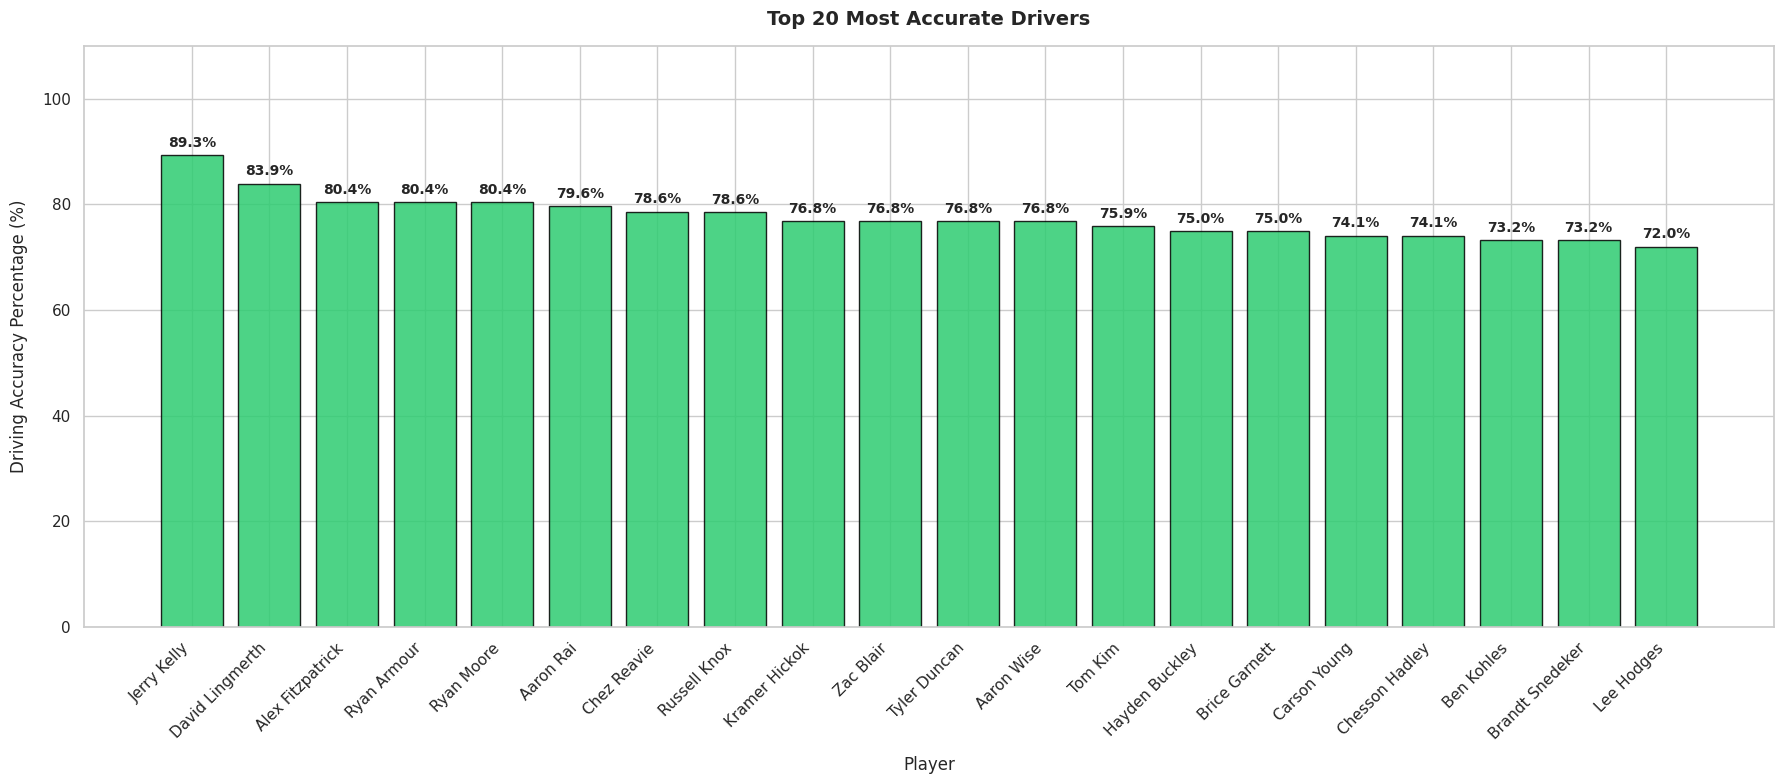

In [15]:
# Plot
# 1. Grab the top players
top_accuracy = player_accuracy_df.head(20)

# 2. Set up the plot appearance
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 8))

# 3. Create a sorted bar chart
bars = plt.bar(
    top_accuracy['player'].astype(str),  # Convert to string so it treats IDs as categories
    top_accuracy['driving_accuracy_%'],
    color='#2ecc71',
    edgecolor='black',
    alpha=0.85
)

# 4. Add the exact percentage values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# 5. Labels and Formatting
plt.title("Top 20 Most Accurate Drivers", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Player", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Driving Accuracy Percentage (%)", fontsize=12, labelpad=10)
plt.ylim(0, 110)  # Adds extra headroom for the text labels

plt.tight_layout()
plt.show()


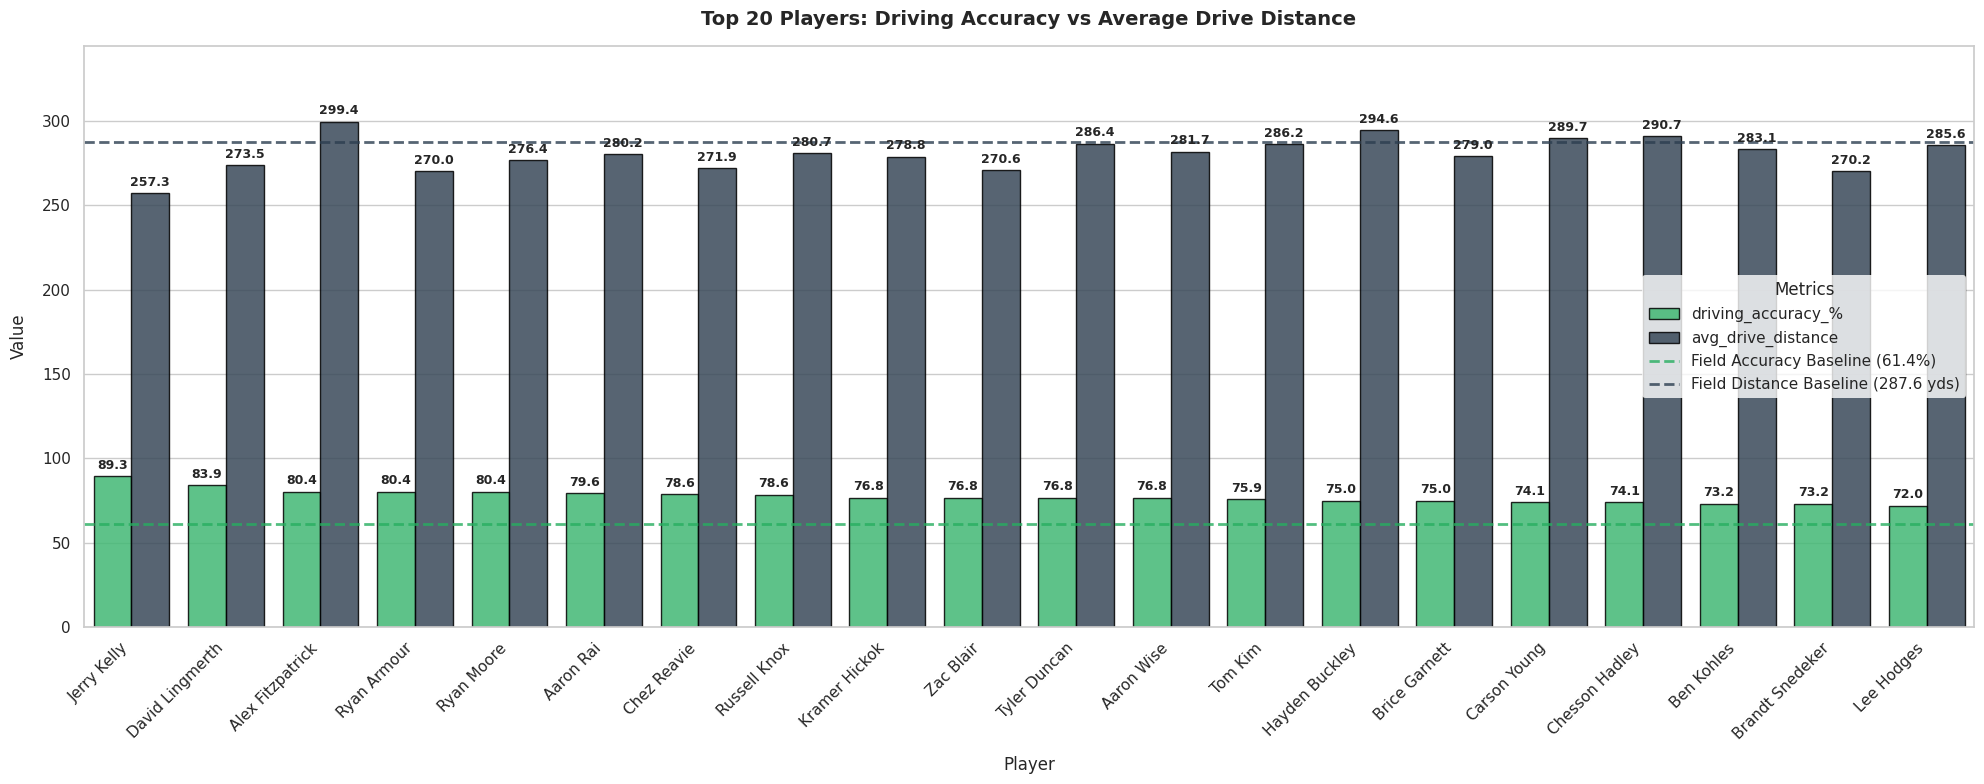

In [16]:
def plot_top_20_players_drive_accuracy(data):
    # 1. Grab the top players
    top_accuracy = data.head(20)

    # Get baselines
    baseline_accuracy = data['driving_accuracy_%'].mean()
    baseline_distance = data['avg_drive_distance'].mean()

    # 2. Reshape the data so both metrics are in a single column for Seaborn
    # (Replace 'total_drives_tracked' with whatever second column name you want to plot)
    melted_df = pd.melt(
        top_accuracy,
        id_vars=['player'],
        value_vars=['driving_accuracy_%', 'avg_drive_distance'],
        var_name='Metric',
        value_name='Value'
    )

    # 3. Set up the plot appearance
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 8))

    # 4. Create the grouped bar chart using Seaborn
    # 'hue' splits the bars side-by-side automatically
    ax = sns.barplot(
        data=melted_df,
        x='player',
        y='Value',
        hue='Metric',
        palette=['#2ecc71', '#34495e'],  # Green for accuracy, Dark Grey for the second metric
        edgecolor='black',
        alpha=0.85
    )

    # 5. Add the exact values on top of each individual bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9, fontweight='bold', padding=3)

    # Green dashed line for Accuracy
    ax.axhline(
        y=baseline_accuracy,
        color='#27ae60',
        linestyle='--',
        linewidth=2,
        alpha=0.8,
        label=f'Field Accuracy Baseline ({baseline_accuracy:.1f}%)'
    )

    # Dark Grey dashed line for Distance
    ax.axhline(
        y=baseline_distance,
        color='#2c3e50',
        linestyle='--',
        linewidth=2,
        alpha=0.8,
        label=f'Field Distance Baseline ({baseline_distance:.1f} yds)'
    )

    # 6. Labels and Formatting
    plt.title("Top 20 Players: Driving Accuracy vs Average Drive Distance", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Player", fontsize=12, labelpad=10)
    plt.ylabel("Value", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')

    # Dynamic headroom limit based on the maximum value in your selected columns
    max_val = melted_df['Value'].max()
    plt.ylim(0, max_val * 1.15)

    # Style the legend cleanly
    plt.legend(title="Metrics", frameon=True, facecolor='white', edgecolor='none')

    plt.tight_layout()
    plt.show()

plot_top_20_players_drive_accuracy(player_accuracy_df)

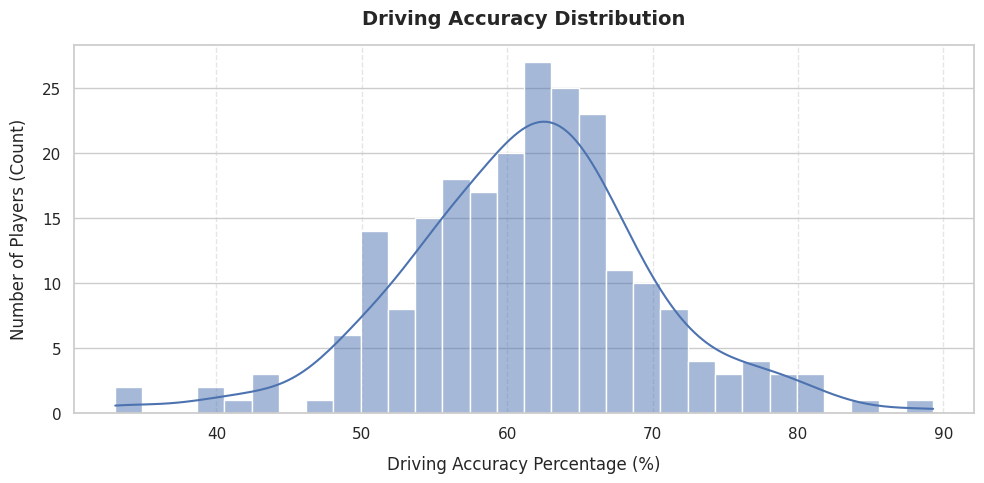

In [17]:
def plot_drive_accuracy_distribution(data):
    plt.figure(figsize=(10, 5))

    # Create a histogram with a smooth Kernel Density Estimate (KDE) line
    sns.histplot(
        data=data,
        x='driving_accuracy_%',
        kde=True,
        bins=30,
        edgecolor='white'
    )

    # Labels and Formatting
    plt.title("Driving Accuracy Distribution", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Driving Accuracy Percentage (%)", fontsize=12, labelpad=10)
    plt.ylabel("Number of Players (Count)", fontsize=12, labelpad=10)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_drive_accuracy_distribution(player_accuracy_df)

## Approach Analysis

### Greens in Regulation (GIR)

check if shot onto green shot number is within threshold

* shot_number <= 1 on par 3
* shot_number <= 2 on par 4
* shot_number <= 3 on par 5

In [37]:
# df_R2025011 = df[df['tournament_id'] == 'R2025011']
df_R2025011 = df

def get_gir(df):
    green_shots = df[df['location'].str.lower().str.contains('green', na=False)].copy()

    # Find the first shot that hit the green for every player on every hole
    # (Using groupby + min ensures we catch the exact shot number they reached the surface)
    first_green_shot = green_shots.groupby(['round', 'hole', 'player', 'par'])['shot_number'].min().reset_index()
    first_green_shot.rename(columns={'shot_number': 'shot_reached_green'}, inplace=True)

    # Apply the official GIR condition: shot_reached_green <= (par - 2)
    first_green_shot['GIR'] = first_green_shot['shot_reached_green'] <= (first_green_shot['par'] - 2)

    # return first_green_shot[['player', 'par', 'shot_reached_green', 'GIR']]
    return first_green_shot

def get_gir_percentage(df):
    gir = get_gir(df)

    # Calculate final GIR %
    player_gir_df = gir.groupby('player')['GIR'].mean().reset_index()

    # Get the percentage
    player_gir_df['GIR_%'] = (player_gir_df['GIR'] * 100).round(2)
    player_gir_df = player_gir_df.sort_values(by='GIR_%', ascending=False).reset_index(drop=True)

    # Clean up temporary aggregation column
    player_gir_df.drop(columns=['GIR'], inplace=True)
    return player_gir_df

gir = get_gir_percentage(df_R2025011)
gir.head(10)

,player,GIR_%
0,Nate Lashley,100.00
1,Adam Schenk,98.61
2,Luke List,98.61
3,Rory McIlroy,98.61
4,Emiliano Grillo,98.61
5,Erik van Rooyen,97.22
6,Justin Lower,97.22
7,Taylor Moore,97.22
8,Tyler Duncan,97.22
9,Mark Hubbard,97.22


In [19]:
gir['GIR_%'].mean()

np.float64(78.56478260869567)

#### Plots

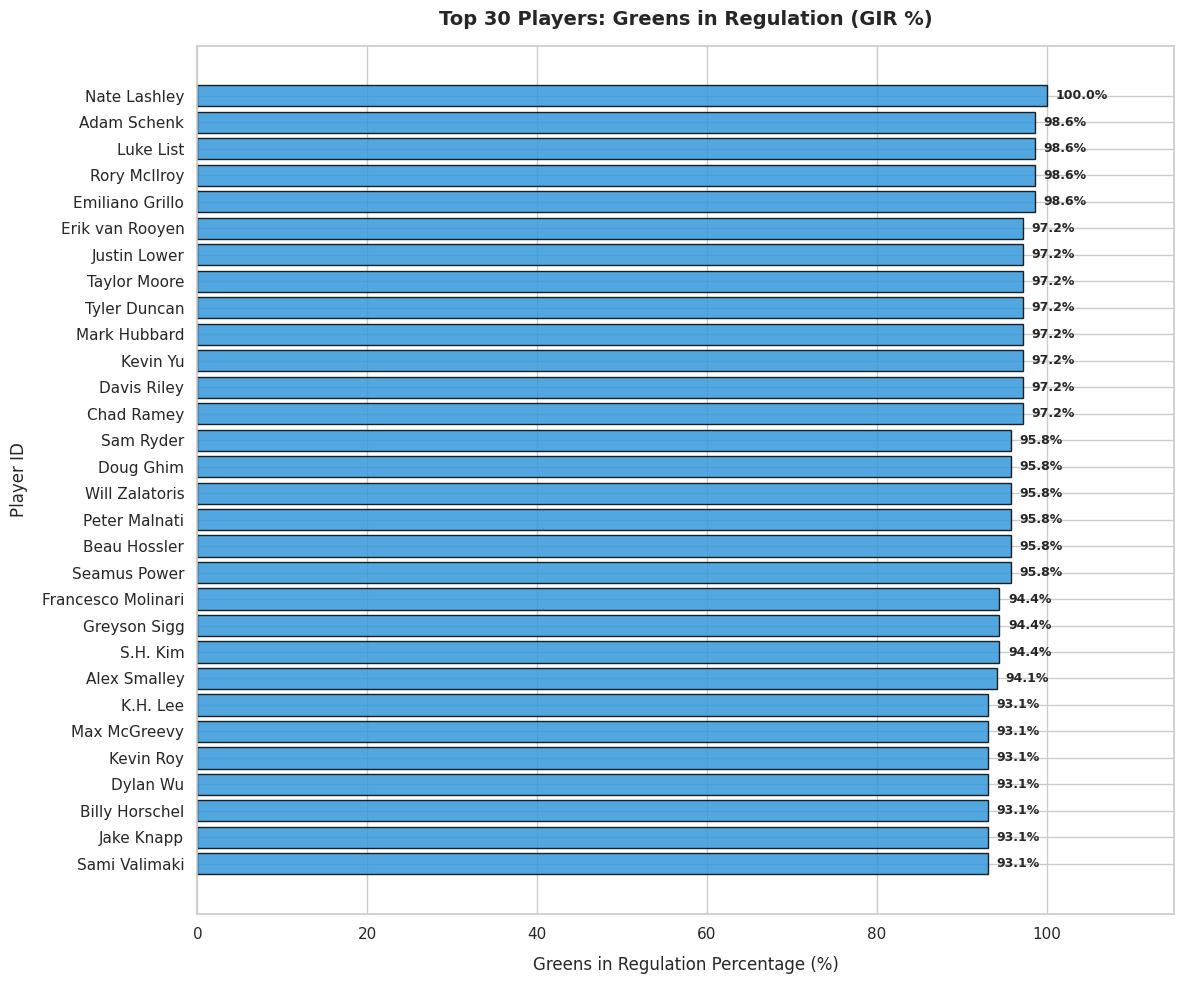

In [20]:
def plot_top_30_players_gir(players_gir_data):
    # Plot
    # 1. Grab the top 30 players for GIR
    top_30_gir = players_gir_data.head(30)

    # 2. Set up style and sizing
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 10))

    # 3. Plot horizontal bars (notice we swap x and y)
    bars = plt.barh(
        top_30_gir['player'].astype(str),
        top_30_gir['GIR_%'],
        color='#3498db',  # Clean tournament blue
        edgecolor='black',
        alpha=0.85
    )

    # 4. Invert the Y-axis so the #1 player sits proudly at the very top
    plt.gca().invert_yaxis()

    # 5. Add text percentage values to the right tip of each bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 1,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    # 6. Labels and Formatting
    plt.title("Top 30 Players: Greens in Regulation (GIR %)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Greens in Regulation Percentage (%)", fontsize=12, labelpad=10)
    plt.ylabel("Player ID", fontsize=12, labelpad=10)
    plt.xlim(0, 115)  # Add room on the right edge for percentage text labels

    plt.tight_layout()
    plt.show()

plot_top_30_players_gir(gir)

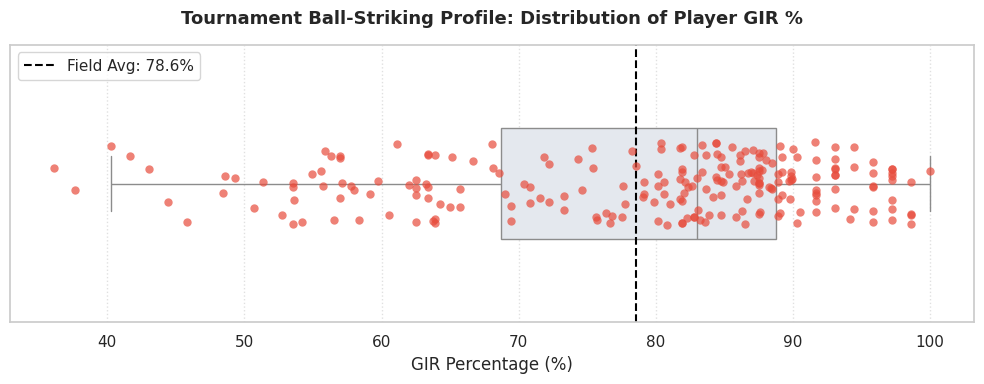

In [21]:
# Plot
plt.figure(figsize=(10, 4))

# 1. Create a light gray background box plot to show the baseline quartile markers
sns.boxplot(
    data=gir,
    x='GIR_%',
    color='#e2e8f0',
    width=0.4,
    fliersize=0
)

# 2. Overlay every individual player as a distinct point so you see the raw density
sns.stripplot(
    data=gir,
    x='GIR_%',
    color='#e74c3c',  # Vibrant red dots for players
    size=6,
    alpha=0.7,
    jitter=0.15
)

# 3. Add a vertical line showcasing the overall field average
field_mean = gir['GIR_%'].mean()
plt.axvline(field_mean, color='black', linestyle='--', linewidth=1.5, label=f'Field Avg: {field_mean:.1f}%')

# 4. Labels and Formatting
plt.title("Tournament Ball-Striking Profile: Distribution of Player GIR %", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("GIR Percentage (%)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Proximity to Hole

Average remaining distance to hole (to_hole_yards) after approach shot.

In [ ]:
def get_avg_proximity_to_hole_after_approach_shot(df):
    # Get next shot remaining distance
    # Make sure sorted
    df_sorted = df.sort_values(by=['tournament_id', 'round', 'hole', 'player', 'shot_number']).copy()

    # Get the starting distance of the *next* shot (the remaining distance after current shot)
    df_sorted['remaining_dist_after_shot'] = df_sorted.groupby(['tournament_id', 'round', 'hole', 'player'])['to_hole_yards'].shift(-1)

    # If the next shot is on the green, convert feet/inches to yards for uniform proximity tracking
    # df_sorted['remaining_dist_after_shot'] = df_sorted['remaining_dist_after_shot'].apply(convert_to_yards)

    # Filter Approach Shots
    approach_shots = df_sorted[df_sorted['shot_type'].str.lower().str.contains('approach', na=False)].copy()

    # Create new df
    player_proximity_df = pd.DataFrame({
        'avg_proximity_after_approach_shot_yards': approach_shots.groupby('player')['remaining_dist_after_shot'].mean(),
        'approach_shots_measured': approach_shots.groupby('player')['remaining_dist_after_shot'].count()
    }).reset_index()

    # Sort from closest proximity (best) to furthest away (worst)
    player_proximity_df = player_proximity_df.sort_values(by='avg_proximity_after_approach_shot_yards', ascending=True).reset_index(drop=True)

    # Clean up any players with low sample sizes if necessary
    leaderboard_proximity = player_proximity_df[player_proximity_df['approach_shots_measured'] >= 5]
    # convert to feet
    leaderboard_proximity['avg_proximity_after_approach_shot_feet'] = (leaderboard_proximity['avg_proximity_after_approach_shot_yards'] * 3).round(1)
    return leaderboard_proximity

proximity_df = get_avg_proximity_to_hole_after_approach_shot(df)
proximity_df.head()

,player,avg_proximity_after_approach_shot_yards,approach_shots_measured,avg_proximity_after_approach_shot_feet
0,Alex Fitzpatrick,1.231365,85,3.7
1,Laurie Canter,1.361827,104,4.1
2,Scottie Scheffler,1.441472,527,4.3
3,Matt NeSmith,1.457506,83,4.4
4,Matthias Schwab,1.652886,105,5.0


## Short Game Analysis

### Scrambling Percentage

Percentage player scores par/better after missing GIR.

$$Scrambling \ Percentage = \frac{Number \ Par \ Saves \ When \ Miss \ GIR}{total \ Num \ Holes \ Where \ GIR \ Missed} \times 100$$

In [22]:
def get_scrambling_percentage(df):
    # Identify missed GIR and final scores
    hole_scores = get_hole_scores(df)
    green_shots = df[df['location'].str.lower().str.contains('green', na=False)].copy()
    first_green_shot = green_shots.groupby(['round', 'hole', 'player', 'par'])['shot_number'].min().reset_index()
    first_green_shot.rename(columns={'shot_number': 'shot_reached_green'}, inplace=True)

    # Merge hole scores and green data together
    scramble_base = pd.merge(hole_scores, first_green_shot, on=['round', 'hole', 'player'], how='left')

    # If 'shot_reached_green' is NaN, it means they never hit the green at all
    # Let's fill those with a high dummy number so it safely counts as a missed GIR.
    scramble_base['shot_reached_green'] = scramble_base['shot_reached_green'].fillna(99)

    # Run scrambling flags

    # Flag 1: Did the player miss the green in regulation?
    scramble_base['missed_GIR'] = scramble_base['shot_reached_green'] > (scramble_base['par'] - 2)

    # Flag 2: Did the player make par or better?
    scramble_base['saved_par'] = scramble_base['total_shots'] <= scramble_base['par']

    # Isolate ONLY the opportunities where the player actually missed the green
    scramble_opportunities = scramble_base[scramble_base['missed_GIR'] == True].copy()

    # Compile scrambling dataframe

    # Create the new standalone DataFrame
    player_scrambling_df = pd.DataFrame({
        'scrambling_%': (scramble_opportunities.groupby('player')['saved_par'].mean() * 100).round(2),
        'scramble_opportunities': scramble_opportunities.groupby('player')['saved_par'].count(),
        'scramble_saves': scramble_opportunities.groupby('player')['saved_par'].sum()
    }).reset_index()

    # Sort from best scrambler to worst
    player_scrambling_df = player_scrambling_df.sort_values(by='scrambling_%', ascending=False).reset_index(drop=True)
    return player_scrambling_df

player_scrambling_df = get_scrambling_percentage(df_R2025011)
player_scrambling_df.head(10)

,player,scrambling_%,scramble_opportunities,scramble_saves
0,K.H. Lee,93.33,15,14
1,Doug Ghim,88.89,9,8
2,Will Gordon,85.00,20,17
3,Billy Horschel,80.00,15,12
4,Matthias Schwab,78.79,33,26
5,Denny McCarthy,77.45,102,79
6,Danny Willett,77.27,22,17
7,Troy Merritt,76.47,34,26
8,Rory McIlroy,75.00,4,3
9,Robert Streb,73.08,26,19


In [23]:
player_scrambling_df['scrambling_%'].mean()

np.float64(53.98545851528385)

### Sand Saves

Groupby holes where a players location was in the sand/bunker within 50 ft of hole and see if finish in 2 shots or fewer.

In [24]:
def get_player_sand_saves(df):
    hole_scores = get_hole_scores(df)

    # Make sure shots are in order
    df_sorted = df.sort_values(by=['round', 'hole', 'player', 'shot_number']).copy()

    # Look at the next shot's location using .shift(-1)
    df_sorted['next_location'] = df_sorted.groupby(['round', 'hole', 'player'])['location'].shift(-1)

    # Filter for shots hit from a bunker that landed on the green (Using 'bunker' catches green-side sand shots)
    sand_to_green = df_sorted[
        df_sorted['location'].str.lower().str.contains('bunker', na=False) &
        df_sorted['next_location'].str.lower().str.contains('green', na=False)
    ].copy()

    # Mark these holes as having a valid sand-save opportunity
    sand_to_green['had_sand_opportunity'] = True

    # Keep just one record per hole for players who hit out of the sand to the green
    sand_opportunities = sand_to_green.drop_duplicates(subset=['round', 'hole', 'player', 'par'])

    # Merge and flag sand saves
    sand_base = pd.merge(
        hole_scores,
        sand_opportunities[['round', 'hole', 'player', 'had_sand_opportunity', 'par']],
        on=['round', 'hole', 'player'],
        how='inner' # 'inner' drops any holes where they never went bunker-to-green
    )

    # A sand save is successful if their final score is less than or equal to par
    sand_base['is_sand_save'] = sand_base['total_shots'] <= sand_base['par']

    # Create leaderboard
    player_sand_saves_df = pd.DataFrame({
        'sand_save_%': (sand_base.groupby('player')['is_sand_save'].mean() * 100).round(2),
        'sand_opportunities': sand_base.groupby('player')['is_sand_save'].count(),
        'sand_saves_made': sand_base.groupby('player')['is_sand_save'].sum()
    }).reset_index()

    # Sort the table from best sand-scrambler to worst
    return player_sand_saves_df.sort_values(by='sand_save_%', ascending=False).reset_index(drop=True)

player_sand_saves_df = get_player_sand_saves(df_R2025011)
player_sand_saves_df.head(100)

,player,sand_save_%,sand_opportunities,sand_saves_made
0,Henrik Norlander,100.00,1,1
1,James Hahn,100.00,5,5
2,Frankie Capan III,100.00,1,1
3,Vincent Norrman,100.00,4,4
4,Laurie Canter,100.00,4,4
...,...,...,...,...
95,Kurt Kitayama,76.00,100,76
96,Corey Conners,75.64,156,118
97,Michael Kim,75.45,110,83
98,Collin Morikawa,75.45,110,83


In [25]:
player_sand_saves_df['sand_save_%'].mean()

np.float64(71.33375545851528)

#### Plots

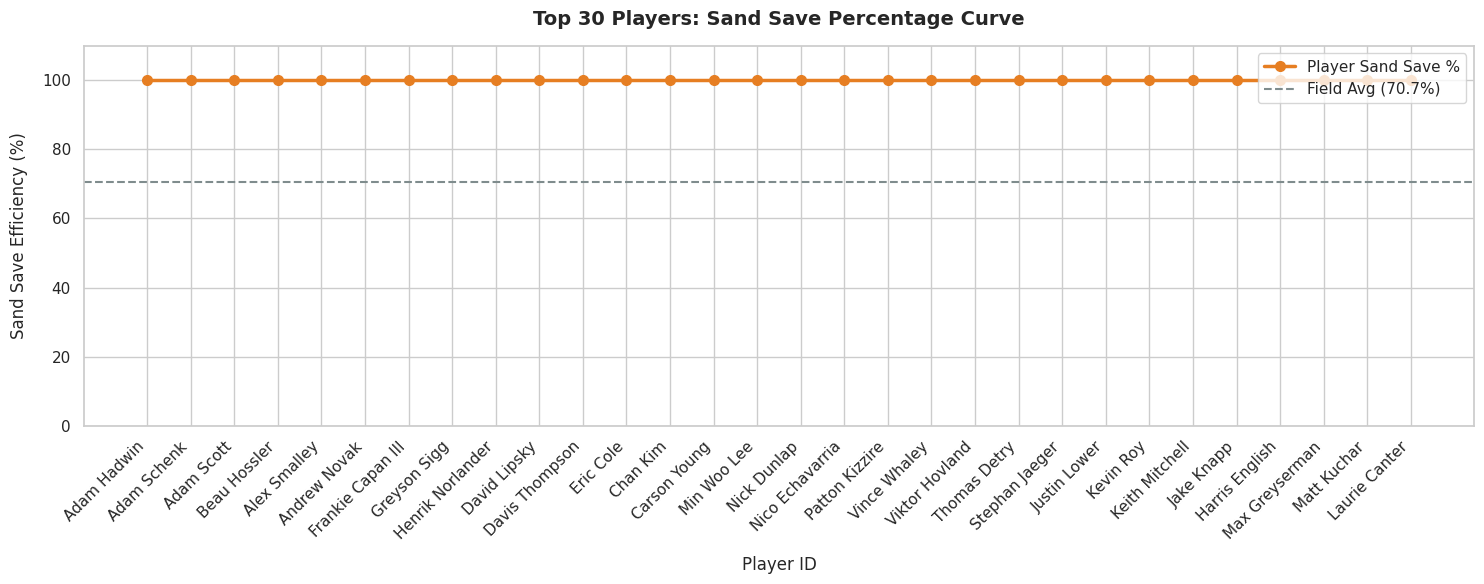

In [ ]:
def plot_sand_saves(sand_saves_data):
    # Plot
    # 1. Grab your top 30 sand-savers (or plot the whole field)
    top_sand_players = sand_saves_data.head(30)

    # 2. Set up the plotting canvas
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 6))

    # 3. Plot the performance line
    plt.plot(
        top_sand_players['player'].astype(str),  # X-axis: Player IDs as strings
        top_sand_players['sand_save_%'],           # Y-axis: Sand Save %
        color='#e67e22',                            # Bunker-orange line
        marker='o',                                 # Distinct dots at each player node
        linewidth=2.5,
        markersize=7,
        label='Player Sand Save %'
    )

    # 4. Add a horizontal line representing the overall field average
    field_sand_avg = sand_saves_data['sand_save_%'].mean()
    plt.axhline(
        y=field_sand_avg,
        color='#7f8c8d',
        linestyle='--',
        linewidth=1.5,
        label=f'Field Avg ({field_sand_avg:.1f}%)'
    )

    # 5. Labels and Axis Tweak
    plt.title("Top 30 Players: Sand Save Percentage Curve", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Player ID", fontsize=12, labelpad=10)
    plt.ylabel("Sand Save Efficiency (%)", fontsize=12, labelpad=10)

    # Rotate the player IDs so they don't crowd each other
    plt.xticks(rotation=45, ha='right')

    # Give some vertical headroom for clean viewing
    plt.ylim(0, 110)

    # Place the legend cleanly
    plt.legend(loc='upper right', frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

plot_sand_saves(player_sand_saves_df)

## Putting Analysis

In [34]:
# df_R2025011 = df[df['tournament_id'] == 'R2025011']
df_R2025011 = df
putts_df = df_R2025011[df_R2025011['shot_type'] == 'Putt'].copy()

avg_putt_distance = putts_df['shot_dist_yards'].mean()
print(f"Average Putt Distance: {avg_putt_distance:.2f} yards")

Average Putt Distance: 4.32 yards


### Putts per Round and Putts per GIR

In [41]:
def get_player_putts_per_gir(df):
    # Get putts
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    # Group by player and round to count their total putts
    round_putts = putts_df.groupby(["round", "player"]).size().reset_index(name="total_putts")

    # Get average putts per round
    player_putts_per_round = round_putts.groupby("player")["total_putts"].mean().reset_index(name="putts_per_round")
    player_putts_per_round["putts_per_round"] = player_putts_per_round["putts_per_round"].round(2)

    # Get Putts per GIR

    # Count the number of putts taken on every hole
    hole_putts = putts_df.groupby(["round", "hole", "player"]).size().reset_index(name='hole_putt_count')
    hole_putts = hole_putts[
        (hole_putts['player'] == 'Cameron Young') &
        (hole_putts['round'] == 1) &
        (hole_putts['hole'] == 1)
    ]
    print(hole_putts)

    # Get 'GIR' boolean column (True/False)
    gir_df = get_gir(df)
    gir_putts_base = pd.merge(
        gir_df[['round', 'hole', 'player', 'GIR']],
        hole_putts,
        on=['round', 'hole', 'player'],
        how='left'
    )

    # Fill NaN with 0 for holes where they holed out from off the green and took 0 putts
    gir_putts_base['hole_putt_count'] = gir_putts_base['hole_putt_count'].fillna(0)

    # Isolate only the holes where the player successfully made a GIR
    gir_only_holes = gir_putts_base[gir_putts_base['GIR'] == True]

    # Calculate the final average putts per GIR
    # player_putts_per_gir = gir_only_holes.groupby('player').size().reset_index(name='putts_per_gir') # total counts
    return gir_only_holes.groupby('player')['hole_putt_count'].mean().reset_index(name='putts_per_gir') # average

player_putts_per_gir = get_player_putts_per_gir(df_R2025011)
player_putts_per_gir.head()

    round  hole         player  hole_putt_count
38      1     1  Cameron Young               13


,player,putts_per_gir
0,A.J. Ewart,0.0
1,Aaron Baddeley,0.0
2,Aaron Rai,0.0
3,Aaron Wise,0.0
4,Adam Hadwin,0.0


In [32]:
df['shot_type'].value_counts()

,count
shot_type,
Putt,80477
Approach,70315
Tee,49674


In [40]:
player_putts_per_gir['putts_per_gir'].mean()

np.float64(0.0009043478260869564)

### Putt Percentage

How often 1 putts, 2 putt, 3 putts, and more than 3 putts?

In [28]:
def get_putt_percentages(df):
    # Get putts
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    hole_putts = putts_df.groupby(["round", "hole", "par", "player"]).size().reset_index(name="total_putts")
    hole_putts.head()

    # Create boolean flags for putt numbers
    hole_putts['is_1_putt'] = hole_putts['total_putts'] == 1
    hole_putts['is_2_putt'] = hole_putts['total_putts'] == 2
    hole_putts['is_3_putt'] = hole_putts['total_putts'] == 3
    hole_putts['is_3+_putt'] = hole_putts['total_putts'] > 3

    # Calculate percentage of 1, 2, 3, 3+ putts
    return pd.DataFrame({
        '1_putt_%': (hole_putts.groupby('player')['is_1_putt'].mean() * 100).round(2),
        '2_putt_%': (hole_putts.groupby('player')['is_2_putt'].mean() * 100).round(2),
        '3_putt_%': (hole_putts.groupby('player')['is_3_putt'].mean() * 100).round(2),
        '3+_putt_%': (hole_putts.groupby('player')['is_3+_putt'].mean() * 100).round(2),
    }).reset_index()

putt_percentages = get_putt_percentages(df_R2025011)
putt_percentages.head()

,player,1_putt_%,2_putt_%,3_putt_%,3+_putt_%
0,A.J. Ewart,45.83,48.61,5.56,0.00
1,Aaron Baddeley,2.78,15.28,26.39,55.56
2,Aaron Rai,16.07,19.64,0.00,64.29
3,Aaron Wise,52.11,42.25,5.63,0.00
4,Adam Hadwin,14.66,23.28,2.59,59.48


### Putting Percentage by Distance

Group putting into distances like under 5 ft, 5-10 feet, and over 10 feet,

In [ ]:
hole_putts = putts_df.groupby(["round", "hole", "par", "player", "to_hole_yards"]).size().reset_index(name="total_putts")
hole_putts.head()

# Create boolean flags for putt distances
hole_putts['is_under_5'] = hole_putts['to_hole_yards'] > 5/3
hole_putts['is_5_10'] = (hole_putts['to_hole_yards'] <= 5/3) & (hole_putts['to_hole_yards'] >= 10/3)
hole_putts['is_over_10'] = hole_putts['to_hole_yards'] < 10/3

# Calculate percentage of 1, 2, 3, 3+ putts
putt_dist_percentages = pd.DataFrame({
    'under_5_%': (hole_putts.groupby('player')['is_under_5'].mean() * 100).round(2),
    '5_to_10_%': (hole_putts.groupby('player')['is_5_10'].mean() * 100).round(2),
    'over_10_%': (hole_putts.groupby('player')['is_over_10'].mean() * 100).round(2),
}).reset_index()

putt_dist_percentages.head()

,player,under_5_%,5_to_10_%,over_10_%
0,Aaron Rai,3.57,0.0,99.11
1,Adam Hadwin,7.32,0.0,100.00
2,Adam Schenk,2.52,0.0,100.00
3,Adam Scott,1.94,0.0,100.00
4,Adam Svensson,0.84,0.0,100.00


In [ ]:
# hole_putts = putts_df.groupby(["round", "hole", "par", "player", "to_hole_yards"]).size().reset_index(name="total_putts")
# hole_putts.head()

def get_putt_make_shot_dist_percentages(df):
    putts_df = df[df["shot_type"] == "Putt"].copy()
    putts_df["is_made"] = putts_df["location"].str.lower().str.contains("in hole", na=False)

    # Create boolean flags for putt distances
    hole_putts['is_under_5'] = hole_putts['to_hole_yards'] > 5/3
    hole_putts['is_5_10'] = (hole_putts['to_hole_yards'] <= 5/3) & (hole_putts['to_hole_yards'] >= 10/3)
    hole_putts['is_over_10'] = hole_putts['to_hole_yards'] < 10/3

    # Calculate percentage of 1, 2, 3, 3+ putts
    putt_make_percentages = pd.DataFrame({
        'under_5_make_%': (hole_putts.groupby('player')['is_under_5'].mean() * 100).round(2),
        '5_to_10_make_%': (hole_putts.groupby('player')['is_5_10'].mean() * 100).round(2),
        'over_10_make_%': (hole_putts.groupby('player')['is_over_10'].mean() * 100).round(2),
    }).reset_index()

    # Clean up any players who had 0 putts in a specific distance bin (fills NaN with 0)
    percentage_cols = ['under_5_make_%', '5_to_10_make_%', 'over_10_make_%']
    putt_make_percentages[percentage_cols] = putt_make_percentages[percentage_cols].fillna(0.0)

    # Sort by the best short-range putters
    return putt_make_percentages.sort_values(by='under_5_make_%', ascending=False).reset_index(drop=True)

putt_make_percentages = get_putt_make_shot_dist_percentages(df_R2025011)
putt_make_percentages.head()

,player,under_5_make_%,5_to_10_make_%,over_10_make_%
0,Justin Rose,8.85,0.0,100.00
1,Sami Valimaki,7.56,0.0,99.16
2,Adam Hadwin,7.32,0.0,100.00
3,Patrick Rodgers,6.48,0.0,100.00
4,Carson Young,6.45,0.0,100.00


## In Hole Shot Distance

How far away is player from hole when they make the shot into the hole?

In [28]:
def get_avg_in_hole_shot_distance(df):
    hole_shots = df[df['location'] == 'In Hole'].copy()

    avg_in_hole_dist = hole_shots.groupby(["player"])["shot_dist_yards"].mean().reset_index(name="avg_in_hole_shot_dist")

    # convert yards to feet
    avg_in_hole_dist['avg_in_hole_shot_dist_feet'] = (avg_in_hole_dist['avg_in_hole_shot_dist'] * 3).round(2)

    # sort
    return avg_in_hole_dist.sort_values(by="avg_in_hole_shot_dist_feet", ascending=False)

avg_in_hole_dist = get_avg_in_hole_shot_distance(df)
avg_in_hole_dist.head()

,player,avg_in_hole_shot_dist,avg_in_hole_shot_dist_feet
80,Harrison Endycott,2.968736,8.91
144,Max Greyserman,2.868472,8.61
218,Vince Whaley,2.520514,7.56
2,Aaron Rai,2.497119,7.49
107,Justin Suh,2.293986,6.88


In [30]:
avg_in_hole_dist['avg_in_hole_shot_dist'].mean()

np.float64(1.5320077400333385)

In [31]:
avg_in_hole_dist['avg_in_hole_shot_dist_feet'].mean()


np.float64(4.596391304347827)

### Plot

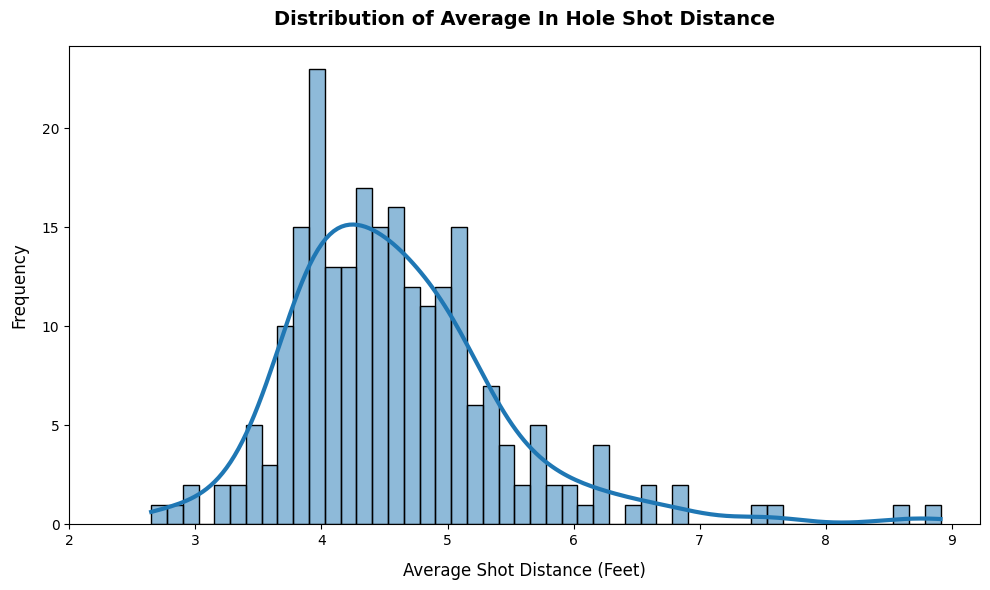

In [29]:
def plot_in_hole_shot_dist_histogram(avg_in_hole_dist):
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the histogram + KDE overlay
    sns.histplot(
        data=avg_in_hole_dist,
        x="avg_in_hole_shot_dist_feet",
        kde=True,
        line_kws={"linewidth": 3, "color": "#e74c3c"}, # Bold red line for the KDE curve
        bins=50,                  # Adjust bin count depending on your dataset size
        ax=ax
    )

    # Gte x tick spacing
    x_min = int(avg_in_hole_dist["avg_in_hole_shot_dist_feet"].min())
    x_max = int(avg_in_hole_dist["avg_in_hole_shot_dist_feet"].max())
    tick_spacing = np.arange(x_min, x_max + 2, step=1)
    ax.set_xticks(tick_spacing)

    ax.set_title("Distribution of Average In Hole Shot Distance", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Average Shot Distance (Feet)", fontsize=12, labelpad=10)
    ax.set_ylabel("Frequency", fontsize=12, labelpad=10)

    plt.tight_layout()

    # Save the visualization as an image file
    # plt.savefig("avg_shot_dist_histogram_kde.png", dpi=300)

plot_in_hole_shot_dist_histogram(avg_in_hole_dist)

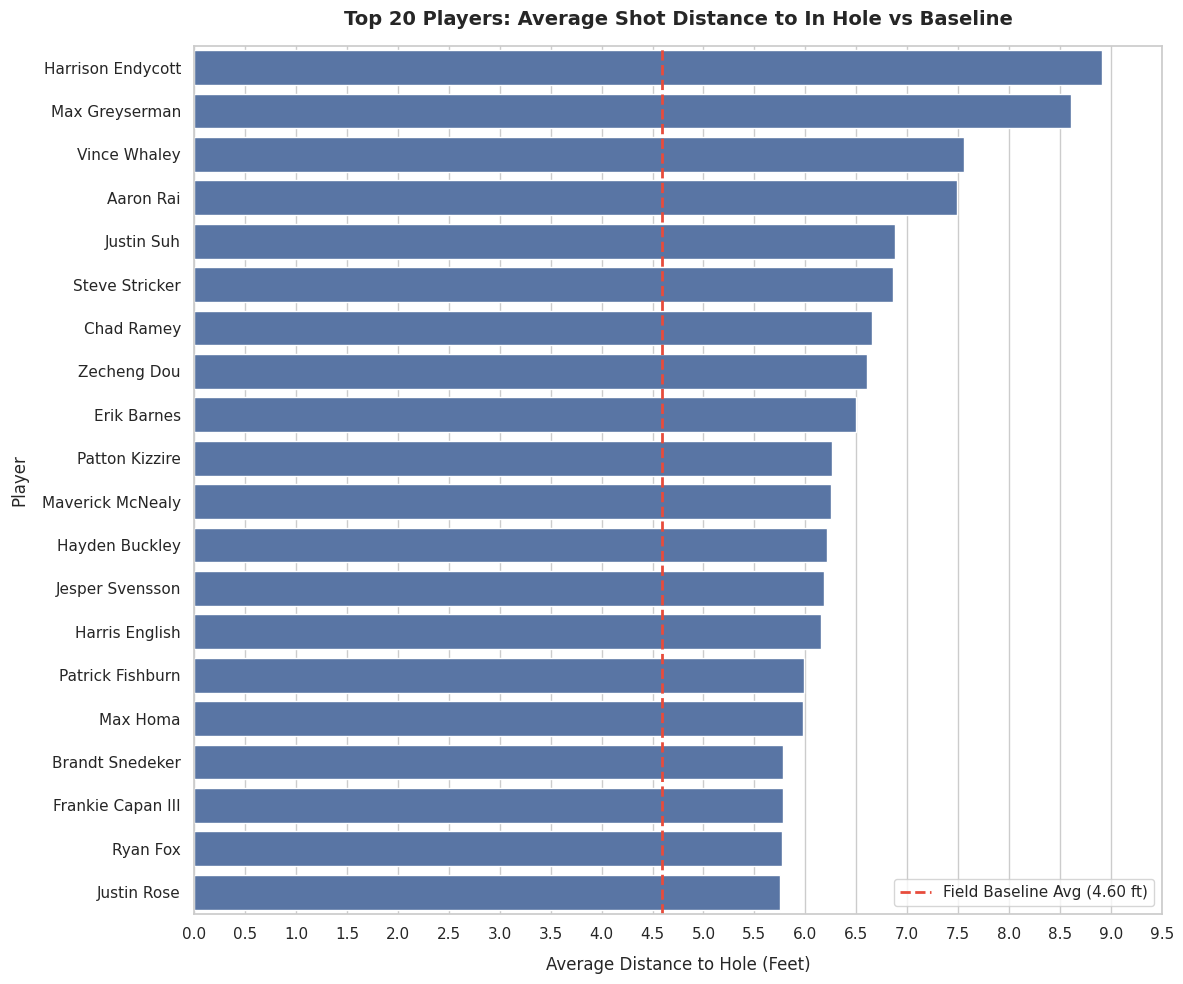

In [ ]:
# Plot
top_20_players = avg_in_hole_dist.head(20)
field_baseline = avg_in_hole_dist['avg_in_hole_shot_dist_feet'].mean()

# 3. Set up the plotting theme and canvas size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 10)) # Tall aspect ratio for vertical list

# 4. Create a horizontal barplot
sns.barplot(
    data=top_20_players,
    x="avg_in_hole_shot_dist_feet",
    y="player",              # Assuming column name is 'player' or 'player_id'
    # hue="player",            # Sets colors by player
    # palette="viridis",       # Smooth color gradient across the field
    legend=False,            # Disables redundant legend
    ax=ax
)

# 5. Draw the Baseline Reference Line
# (Since it's a horizontal bar chart, the baseline line goes vertically across the X axis)
ax.axvline(
    x=field_baseline,
    color="#e74c3c",         # Contrasting red line
    linestyle="--",          # Dashed style
    linewidth=2,
    label=f"Field Baseline Avg ({field_baseline:.2f} ft)"
)

# 6. Adjust X-Axis Number Frequency (Ticks)
# Set marks every 0.5 feet from 0 to the field baseline maximum
import numpy as np
max_x = int(top_20_players["avg_in_hole_shot_dist_feet"].max()) + 2
ax.set_xticks(np.arange(0, max_x, step=0.5))

# 7. Labels and Aesthetics
ax.set_title("Top 20 Players: Average Shot Distance to In Hole vs Baseline", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Average Distance to Hole (Feet)", fontsize=12, labelpad=10)
ax.set_ylabel("Player", fontsize=12, labelpad=10)

# Display the legend for the baseline line
ax.legend(loc="lower right", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

## Stats Between Players

In [ ]:
# Get The Players Championship df
# Using the players championship because have multiple years of data
the_players_champ_df = df[df["tournament"] == "THE PLAYERS Championship"]

# New players stats df
player_df = the_players_champ_df[["player", "player_id"]].drop_duplicates().sort_values(by="player").reset_index(drop=True)

# Get drives, approach, short game, putting, and in hole dist
drive_accuracy = get_drive_accuracy(the_players_champ_df)
gir = get_gir_percentage(the_players_champ_df)
proximity_to_hole = get_avg_proximity_to_hole_after_approach_shot(the_players_champ_df)
scrambling = get_scrambling_percentage(the_players_champ_df)
sand_saves = get_player_sand_saves(the_players_champ_df)
putts_per_gir = get_player_putts_per_gir(the_players_champ_df)
putt_percentages = get_putt_percentages(the_players_champ_df)
putt_make_percentages = get_putt_make_shot_dist_percentages(the_players_champ_df)
in_hole_dist = get_avg_in_hole_shot_distance(the_players_champ_df)

# Merge dataframes
player_stats = (
    player_df
    .merge(drive_accuracy, on="player", how="left")
    .merge(gir, on="player", how="left")
    .merge(proximity_to_hole, on="player", how="left")
    .merge(scrambling, on="player", how="left")
    .merge(sand_saves, on="player", how="left")
    .merge(putts_per_gir, on="player", how="left")
    .merge(putt_percentages, on="player", how="left")
    .merge(putt_make_percentages, on="player", how="left")
    .merge(in_hole_dist, on="player", how="left")
)
player_stats.head()

,player,player_id,driving_accuracy_%,total_drives_tracked,avg_drive_distance,GIR_%,avg_proximity_after_approach_shot_yards,approach_shots_measured,avg_proximity_after_approach_shot_feet,scrambling_%,...,putts_per_gir,1_putt_%,2_putt_%,3_putt_%,3+_putt_%,under_5_make_%,5_to_10_make_%,over_10_make_%,avg_in_hole_shot_dist,avg_in_hole_shot_dist_feet
0,A.J. Ewart,50286,62.50,56,278.250000,43.06,3.136034,116,9.4,53.66,...,1.967742,45.83,48.61,5.56,0.00,NaN,NaN,NaN,1.532806,4.60
1,Aaron Baddeley,22371,59.82,112,276.750000,88.89,4.200824,204,12.6,62.50,...,3.531250,2.78,15.28,26.39,55.56,NaN,NaN,NaN,1.411278,4.23
2,Aaron Rai,46414,81.25,224,282.571429,100.00,2.655224,384,8.0,NaN,...,6.458333,0.00,0.00,0.00,100.00,3.57,0.0,99.11,2.483771,7.45
3,Aaron Wise,49964,76.79,56,281.660714,40.28,8.417056,126,25.3,55.81,...,1.862069,52.11,42.25,5.63,0.00,NaN,NaN,NaN,1.605264,4.82
4,Adam Hadwin,33399,58.33,168,285.982143,93.06,2.669656,279,8.0,20.00,...,5.194030,0.00,1.39,4.17,94.44,7.32,0.0,100.00,1.426468,4.28


/tmp/ipykernel_13020/1843597337.py:45: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  plt.tight_layout()


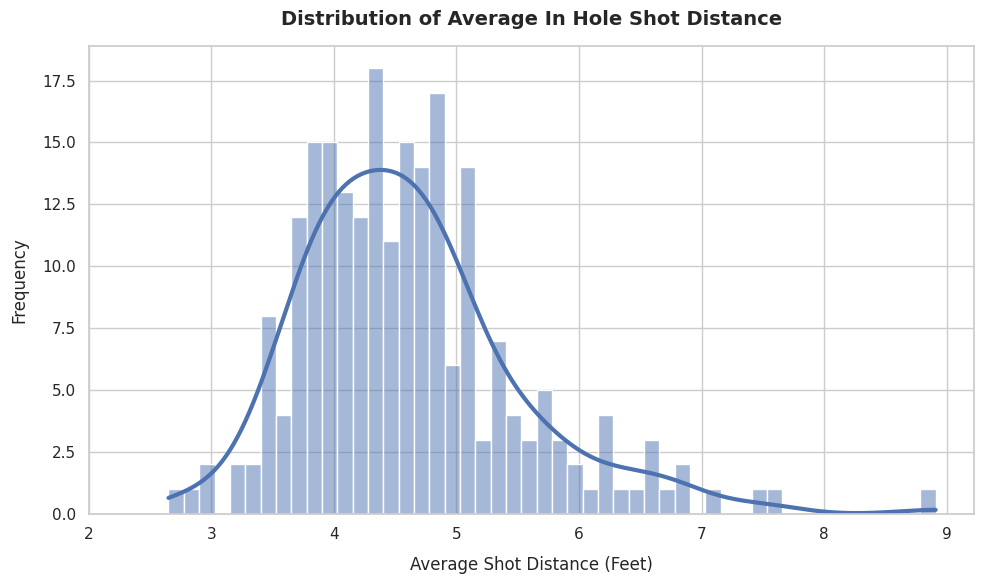

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 133 (\x85) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


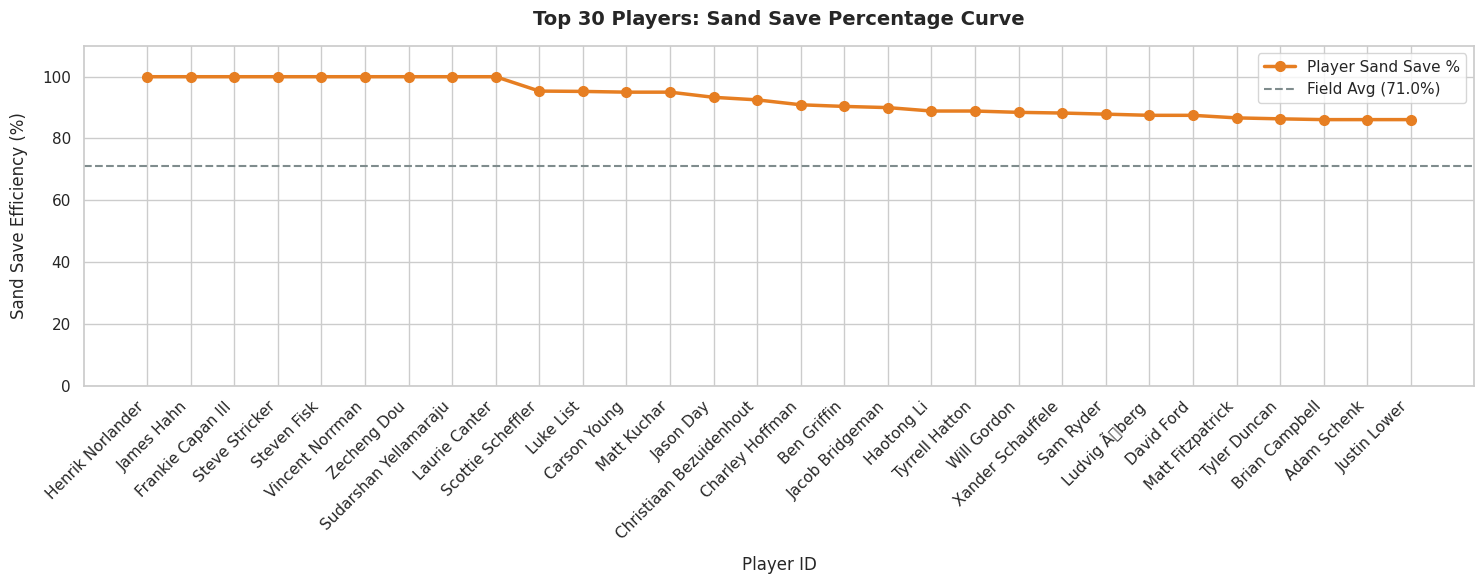

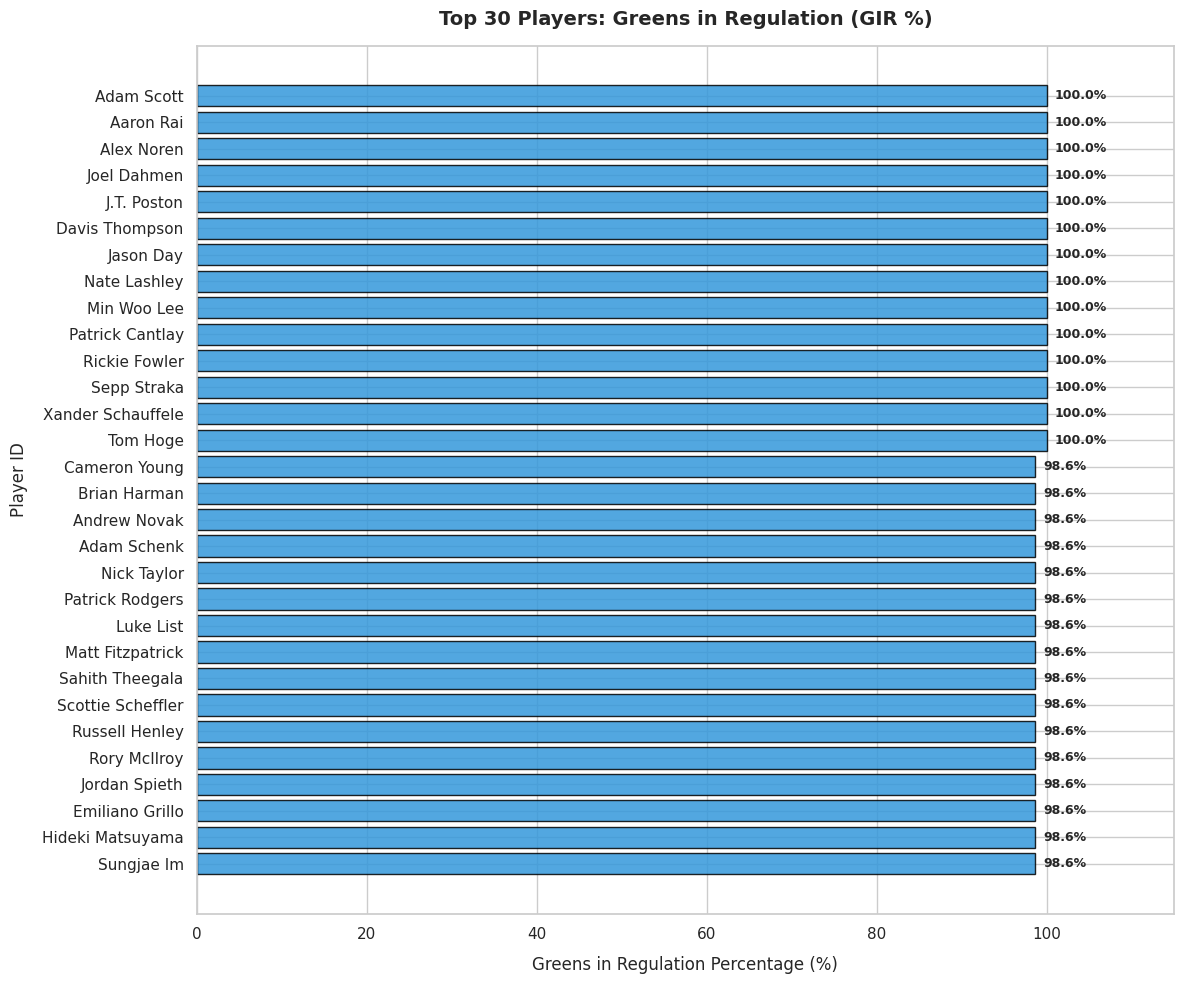

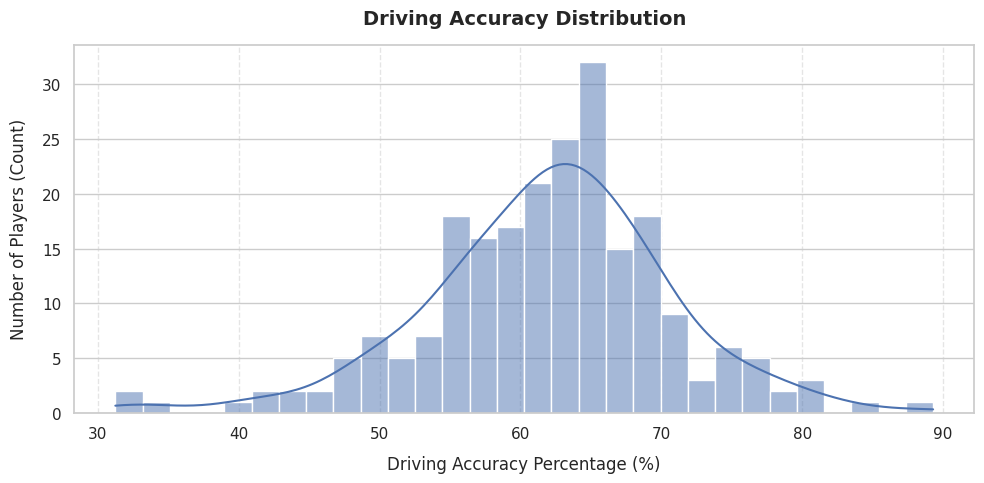

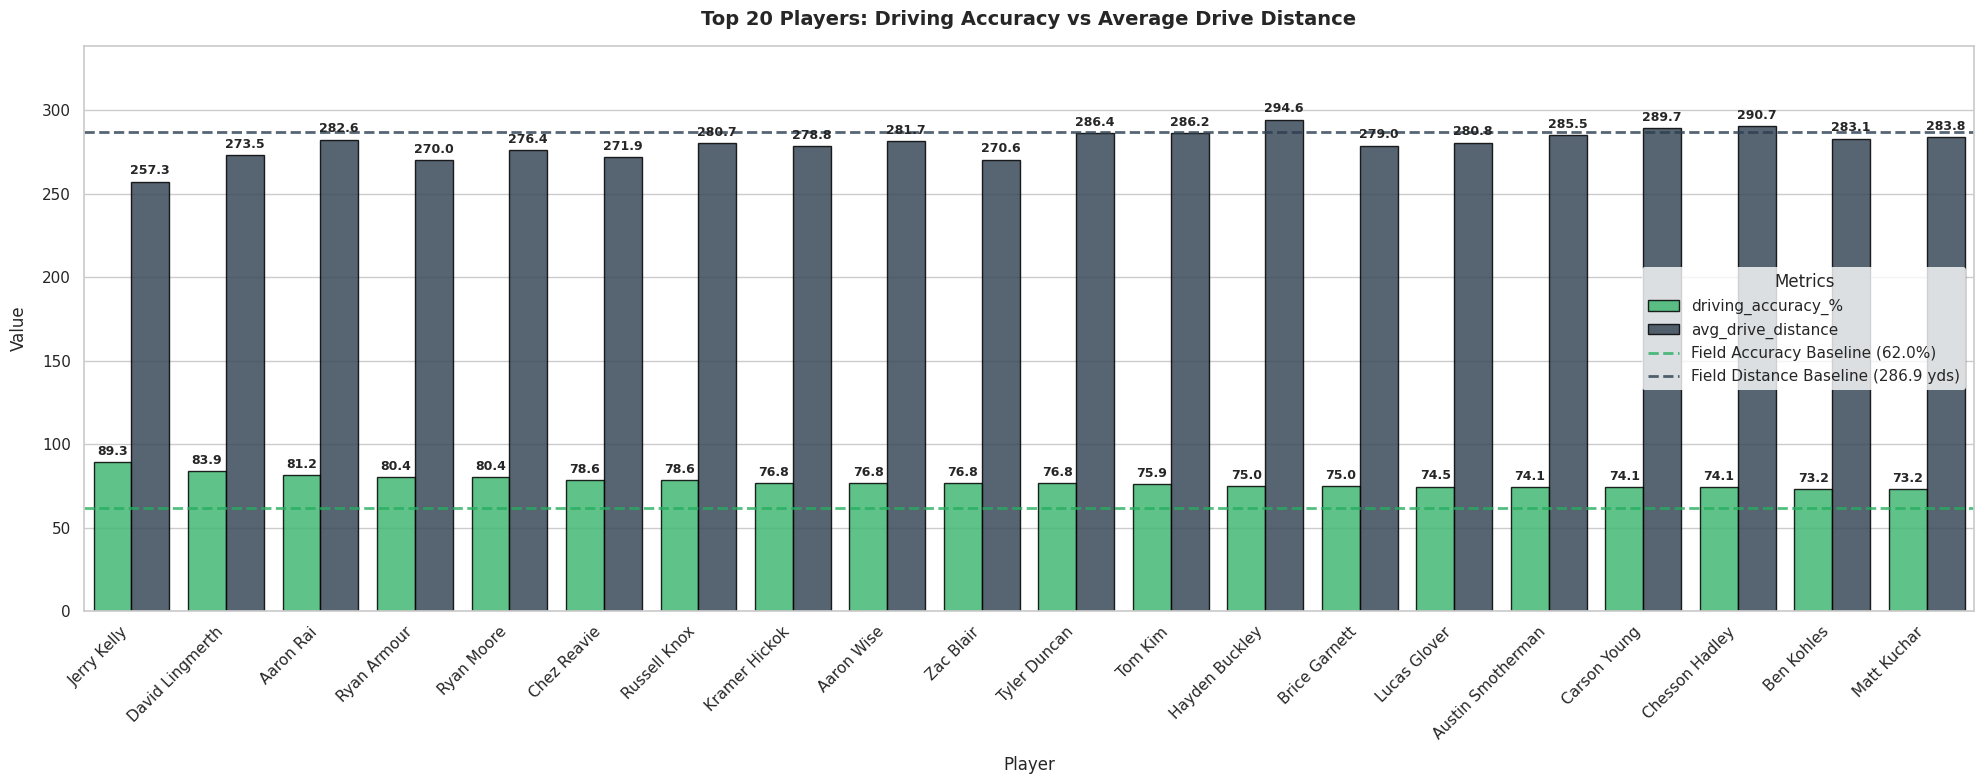

In [ ]:
# Plots
plot_in_hole_shot_dist_histogram(in_hole_dist)
plot_sand_saves(sand_saves)
plot_top_30_players_gir(gir)
plot_drive_accuracy_distribution(drive_accuracy)
plot_top_20_players_drive_accuracy(drive_accuracy)

## The Players Championship Leaderboard

What it should be:

* 2021: Justin Thomas
* 2022: Cameron Smith
* 2023: Scottie Scheffler
* 2024: Scottie Scheffler
* 2025: Roy Mcllroy
* 2026: Cameron Young

In [ ]:
# TODO: leaderboard is wrong because don't have all of 2023 data

In [ ]:
total_scores = get_total_scores(the_players_champ_df)

# grab the top 3 players
top_players = get_top_players(the_players_champ_df, amount=3)

# Sort by strokes ascending (lowest score is best) and grab the top 9 (3 per tournament)
top_3_per_tournament = total_scores.groupby('tournament_id').apply(
    lambda x: x.nsmallest(1, 'total_strokes')
).reset_index(drop=True)
print("\n----- TOURNAMENT LEADERBOARD -----")
print(top_3_per_tournament.to_string(index=False))


----- TOURNAMENT LEADERBOARD -----
           player tournament_id  total_strokes
      Chez Reavie      R2023011          244.0
Scottie Scheffler      R2024011          268.0
       Bud Cauley      R2025011          269.0
    Cameron Young      R2026011          275.0


/tmp/ipykernel_13020/2744483161.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_3_per_tournament = total_scores.groupby('tournament_id').apply(


## Stats between tournaments and players

In [42]:
def get_drive_accuracy_by_tour_and_player(df):
    # Get drives only
    drives_df = df[(df['shot_type'] == 'Tee') & (df['par'] != 3)].copy()

    # If fairway in location then True, else False
    drives_df['hit_fairway'] = drives_df['location'].str.lower().str.contains('fairway', na=False)

    # Get new df with driving accuracy and sort by driving accuracy
    player_accuracy_df = pd.DataFrame({
        'driving_accuracy_%': (drives_df.groupby(['tournament_id', 'player'])['hit_fairway'].mean() * 100).round(2),
        'total_drives_tracked': drives_df.groupby(['tournament_id', 'player'])['hit_fairway'].count(),
        'avg_drive_distance': drives_df.groupby(['tournament_id', 'player'])['shot_dist_yards'].mean()
    }).reset_index()
    player_accuracy_df = player_accuracy_df.sort_values(by='driving_accuracy_%', ascending=False).reset_index(drop=True)

    return player_accuracy_df

def get_gir_by_tour_and_player(df):
    green_shots = df[df['location'].str.lower().str.contains('green', na=False)].copy()

    # Find the first shot that hit the green for every player on every hole
    # (Using groupby + min ensures we catch the exact shot number they reached the surface)
    first_green_shot = green_shots.groupby(['tournament_id', 'round', 'hole', 'player', 'par'])['shot_number'].min().reset_index()
    first_green_shot.rename(columns={'shot_number': 'shot_reached_green'}, inplace=True)

    # Apply the official GIR condition: shot_reached_green <= (par - 2)
    first_green_shot['GIR'] = first_green_shot['shot_reached_green'] <= (first_green_shot['par'] - 2)

    # return first_green_shot[['player', 'par', 'shot_reached_green', 'GIR']]
    return first_green_shot

def get_gir_percentage_by_tour_and_player(df):
    gir = get_gir_by_tour_and_player(df)

    # Calculate final GIR %
    player_gir_df = gir.groupby(['tournament_id', 'player'])['GIR'].mean().reset_index()

    # Get the percentage
    player_gir_df['GIR_%'] = (player_gir_df['GIR'] * 100).round(2)
    player_gir_df = player_gir_df.sort_values(by='GIR_%', ascending=False).reset_index(drop=True)

    # Clean up temporary aggregation column
    player_gir_df.drop(columns=['GIR'], inplace=True)
    return player_gir_df

def get_avg_proximity_to_hole_after_approach_shot_by_tour_and_player(df):
    # Get next shot remaining distance
    # Make sure sorted
    df_sorted = df.sort_values(by=['tournament_id', 'round', 'hole', 'player', 'shot_number']).copy()

    # Get the starting distance of the *next* shot (the remaining distance after current shot)
    df_sorted['remaining_dist_after_shot'] = df_sorted.groupby(['tournament_id', 'round', 'hole', 'player'])['to_hole_yards'].shift(-1)

    # If the next shot is on the green, convert feet/inches to yards for uniform proximity tracking
    # df_sorted['remaining_dist_after_shot'] = df_sorted['remaining_dist_after_shot'].apply(convert_to_yards)

    # Filter Approach Shots
    approach_shots = df_sorted[df_sorted['shot_type'].str.lower().str.contains('approach', na=False)].copy()

    # Create new df
    player_proximity_df = pd.DataFrame({
        'avg_proximity_after_approach_shot_yards': approach_shots.groupby(['tournament_id', 'player'])['remaining_dist_after_shot'].mean(),
        'approach_shots_measured': approach_shots.groupby(['tournament_id', 'player'])['remaining_dist_after_shot'].count()
    }).reset_index()

    # Sort from closest proximity (best) to furthest away (worst)
    player_proximity_df = player_proximity_df.sort_values(by='avg_proximity_after_approach_shot_yards', ascending=True).reset_index(drop=True)

    # Clean up any players with low sample sizes if necessary
    leaderboard_proximity = player_proximity_df[player_proximity_df['approach_shots_measured'] >= 5]
    # convert to feet
    leaderboard_proximity['avg_proximity_after_approach_shot_feet'] = (leaderboard_proximity['avg_proximity_after_approach_shot_yards'] * 3).round(1)
    return leaderboard_proximity

def get_scrambling_percentage_by_tour_and_player(df):
    # Identify missed GIR and final scores
    hole_scores = get_hole_scores(df)
    green_shots = df[df['location'].str.lower().str.contains('green', na=False)].copy()
    first_green_shot = green_shots.groupby(['tournament_id', 'round', 'hole', 'player', 'par'])['shot_number'].min().reset_index()
    first_green_shot.rename(columns={'shot_number': 'shot_reached_green'}, inplace=True)

    # Merge hole scores and green data together
    scramble_base = pd.merge(hole_scores, first_green_shot, on=['tournament_id', 'round', 'hole', 'player'], how='left')

    # If 'shot_reached_green' is NaN, it means they never hit the green at all
    # Let's fill those with a high dummy number so it safely counts as a missed GIR.
    scramble_base['shot_reached_green'] = scramble_base['shot_reached_green'].fillna(99)

    # Run scrambling flags

    # Flag 1: Did the player miss the green in regulation?
    scramble_base['missed_GIR'] = scramble_base['shot_reached_green'] > (scramble_base['par'] - 2)

    # Flag 2: Did the player make par or better?
    scramble_base['saved_par'] = scramble_base['total_shots'] <= scramble_base['par']

    # Isolate ONLY the opportunities where the player actually missed the green
    scramble_opportunities = scramble_base[scramble_base['missed_GIR'] == True].copy()

    # Compile scrambling dataframe

    # Create the new standalone DataFrame
    player_scrambling_df = pd.DataFrame({
        'scrambling_%': (scramble_opportunities.groupby(['tournament_id', 'player'])['saved_par'].mean() * 100).round(2),
        'scramble_opportunities': scramble_opportunities.groupby(['tournament_id', 'player'])['saved_par'].count(),
        'scramble_saves': scramble_opportunities.groupby(['tournament_id', 'player'])['saved_par'].sum()
    }).reset_index()

    # Sort from best scrambler to worst
    player_scrambling_df = player_scrambling_df.sort_values(by='scrambling_%', ascending=False).reset_index(drop=True)
    return player_scrambling_df

def get_player_sand_saves_by_tour_and_player(df):
    hole_scores = get_hole_scores(df)

    # Make sure shots are in order
    df_sorted = df.sort_values(by=['tournament_id', 'round', 'hole', 'player', 'shot_number']).copy()

    # Look at the next shot's location using .shift(-1)
    df_sorted['next_location'] = df_sorted.groupby(['tournament_id', 'round', 'hole', 'player'])['location'].shift(-1)

    # Filter for shots hit from a bunker that landed on the green (Using 'bunker' catches green-side sand shots)
    sand_to_green = df_sorted[
        df_sorted['location'].str.lower().str.contains('bunker', na=False) &
        df_sorted['next_location'].str.lower().str.contains('green', na=False)
    ].copy()

    # Mark these holes as having a valid sand-save opportunity
    sand_to_green['had_sand_opportunity'] = True

    # Keep just one record per hole for players who hit out of the sand to the green
    sand_opportunities = sand_to_green.drop_duplicates(subset=['round', 'hole', 'player', 'par'])

    # Merge and flag sand saves
    sand_base = pd.merge(
        hole_scores,
        sand_opportunities[['tournament_id', 'round', 'hole', 'player', 'had_sand_opportunity', 'par']],
        on=['tournament_id', 'round', 'hole', 'player'],
        how='inner' # 'inner' drops any holes where they never went bunker-to-green
    )

    # A sand save is successful if their final score is less than or equal to par
    sand_base['is_sand_save'] = sand_base['total_shots'] <= sand_base['par']

    # Create leaderboard
    player_sand_saves_df = pd.DataFrame({
        'sand_save_%': (sand_base.groupby(['tournament_id', 'player'])['is_sand_save'].mean() * 100).round(2),
        'sand_opportunities': sand_base.groupby(['tournament_id', 'player'])['is_sand_save'].count(),
        'sand_saves_made': sand_base.groupby(['tournament_id', 'player'])['is_sand_save'].sum()
    }).reset_index()

    # Sort the table from best sand-scrambler to worst
    return player_sand_saves_df.sort_values(by='sand_save_%', ascending=False).reset_index(drop=True)

def get_player_putts_per_gir_by_tour_and_player(df):
    # Get putts
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    # Group by player and round to count their total putts
    round_putts = putts_df.groupby(["tournament_id", "round", "player"]).size().reset_index(name="total_putts")

    # Get average putts per round
    player_putts_per_round = round_putts.groupby(["tournament_id", "player"])["total_putts"].mean().reset_index(name="putts_per_round")
    player_putts_per_round["putts_per_round"] = player_putts_per_round["putts_per_round"].round(2)

    # Get Putts per GIR

    # Count the number of putts taken on every hole
    hole_putts = putts_df.groupby(["tournament_id", "round", "hole", "player"]).size().reset_index(name='hole_putt_count')

    # Get 'GIR' boolean column (True/False)
    gir_df = get_gir_by_tour_and_player(df)
    gir_putts_base = pd.merge(
        gir_df[['tournament_id', 'round', 'hole', 'player', 'GIR']],
        hole_putts,
        on=['tournament_id', 'round', 'hole', 'player'],
        how='left'
    )

    # Fill NaN with 0 for holes where they holed out from off the green and took 0 putts
    gir_putts_base['hole_putt_count'] = gir_putts_base['hole_putt_count'].fillna(0)

    # Isolate only the holes where the player successfully made a GIR
    gir_only_holes = gir_putts_base[gir_putts_base['GIR'] == True]

    # Calculate the final average putts per GIR
    # player_putts_per_gir = gir_only_holes.groupby(['tournament_id', 'player']).size().reset_index(name='putts_per_gir') # total counts
    return gir_only_holes.groupby(['tournament_id', 'player'])['hole_putt_count'].mean().reset_index(name='putts_per_gir') # average

def get_putt_percentages_by_tour_and_player(df):
    # Get putts
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    hole_putts = putts_df.groupby(["tournament_id", "round", "hole", "par", "player"]).size().reset_index(name="total_putts")
    hole_putts.head()

    # Create boolean flags for putt numbers
    hole_putts['is_1_putt'] = hole_putts['total_putts'] == 1
    hole_putts['is_2_putt'] = hole_putts['total_putts'] == 2
    hole_putts['is_3_putt'] = hole_putts['total_putts'] == 3
    hole_putts['is_3+_putt'] = hole_putts['total_putts'] > 3

    # Calculate percentage of 1, 2, 3, 3+ putts
    return pd.DataFrame({
        '1_putt_%': (hole_putts.groupby(['tournament_id', 'player'])['is_1_putt'].mean() * 100).round(2),
        '2_putt_%': (hole_putts.groupby(['tournament_id', 'player'])['is_2_putt'].mean() * 100).round(2),
        '3_putt_%': (hole_putts.groupby(['tournament_id', 'player'])['is_3_putt'].mean() * 100).round(2),
        '3+_putt_%': (hole_putts.groupby(['tournament_id', 'player'])['is_3+_putt'].mean() * 100).round(2),
    }).reset_index()

def get_putt_make_shot_dist_percentages_by_tour_and_player(df):
    putts_only_df = df[df["shot_type"] == "Putt"].copy()
    putts_only_df["is_made"] = putts_only_df["location"].str.lower().str.contains("in hole", na=False)

    # Create boolean flags for putt distances
    putts_only_df['is_under_5'] = putts_only_df['to_hole_yards'] > 5/3
    putts_only_df['is_5_10'] = (putts_only_df['to_hole_yards'] <= 5/3) & (putts_only_df['to_hole_yards'] >= 10/3)
    putts_only_df['is_over_10'] = putts_only_df['to_hole_yards'] < 10/3

    # Calculate percentage of 1, 2, 3, 3+ putts
    putt_make_percentages = pd.DataFrame({
        'under_5_make_%': (putts_only_df.groupby(['tournament_id', 'player'])['is_under_5'].mean() * 100).round(2),
        '5_to_10_make_%': (putts_only_df.groupby(['tournament_id', 'player'])['is_5_10'].mean() * 100).round(2),
        'over_10_make_%': (putts_only_df.groupby(['tournament_id', 'player'])['is_over_10'].mean() * 100).round(2),
    }).reset_index()

    # Clean up any players who had 0 putts in a specific distance bin (fills NaN with 0)
    percentage_cols = ['under_5_make_%', '5_to_10_make_%', 'over_10_make_%']
    putt_make_percentages[percentage_cols] = putt_make_percentages[percentage_cols].fillna(0.0)

    # Sort by the best short-range putters
    return putt_make_percentages.sort_values(by='under_5_make_%', ascending=False).reset_index(drop=True)

def get_avg_in_hole_shot_distance_by_tour_and_player(df):
    hole_shots = df[df['location'] == 'In Hole'].copy()

    avg_in_hole_dist = hole_shots.groupby(["tournament_id", "player"])["shot_dist_yards"].mean().reset_index(name="avg_in_hole_shot_dist")

    # convert yards to feet
    avg_in_hole_dist['avg_in_hole_shot_dist_feet'] = (avg_in_hole_dist['avg_in_hole_shot_dist'] * 3).round(2)

    # sort
    return avg_in_hole_dist.sort_values(by="avg_in_hole_shot_dist_feet", ascending=False)

### Get Mean Values for Stats

In [49]:
drive_accuracy = get_drive_accuracy_by_tour_and_player(df)
gir = get_gir_percentage_by_tour_and_player(df)
proximity_to_hole = get_avg_proximity_to_hole_after_approach_shot_by_tour_and_player(df)
scrambling = get_scrambling_percentage_by_tour_and_player(df)
sand_saves = get_player_sand_saves_by_tour_and_player(df)
putts_per_gir = get_player_putts_per_gir_by_tour_and_player(df)
putt_percentages = get_putt_percentages_by_tour_and_player(df)
putt_make_percentages = get_putt_make_shot_dist_percentages_by_tour_and_player(df)
in_hole_dist = get_avg_in_hole_shot_distance_by_tour_and_player(df)

In [56]:
print("drive acc:     ", drive_accuracy['driving_accuracy_%'].mean().round(2))
print("gir %:         ", gir['GIR_%'].mean().round(2))
print("scrambling:    ", scrambling['scrambling_%'].mean().round(2))
print("sand saves:    ", sand_saves['sand_save_%'].mean().round(2))
print("putts per gir: ", putts_per_gir['putts_per_gir'].mean().round(2))
print("1 putt %:      ", putt_percentages['1_putt_%'].mean().round(2))
print("2 putt %:      ", putt_percentages['2_putt_%'].mean().round(2))
print("3 putt %:      ", putt_percentages['3_putt_%'].mean().round(2))
print("3+ putt %:     ", putt_percentages['3+_putt_%'].mean().round(2))
print("shot make dist:", in_hole_dist['avg_in_hole_shot_dist_feet'].mean().round(2))

drive acc:      61.3
gir %:          63.59
scrambling:     54.39
sand saves:     68.03
putts per gir:  1.8
1 putt %:       40.43
2 putt %:       54.98
3 putt %:       4.46
3+ putt %:      0.14
shot make dist: 4.63


## Strokes Gained

The measurement of difuculty of where ball started versus where ball landed.

$$SG = Value_{Start} - Value_{End} - 1$$

Get strokes gained for "THE PLAYERS Championship" (id `011`).


TODO: add all players championship data (2021-2024).

TODO: how to calculate feild average? use only past years (2021-2025) then calculate SG for 2026 data

### Field Average (the Players 2021-2025)

Calculate feild average of the players championship for years 2021-2025 and leave 2026 for SG analysis.

In [65]:
def get_shots_to_hole(df):
    """
    Get number of shots until makes in hole.
    """
    # total_shots - shot_number
    df["shots_to_hole"] = df["total_shots"] - df["shot_number"]
    return df

def get_field_avg_df(df):
    """
    Get the field average df with hole scores and shots to hole.
    """
    # Get score per hole
    hole_scores = get_hole_scores(df)

    # Add to field_avg_df
    field_avg_df = (
        df
        .merge(hole_scores, on=["tournament_id", "player", "round", "hole"], how="left")
    )

    field_avg_df = get_shots_to_hole(field_avg_df)
    return field_avg_df

# Get players championship 2021-2025
target_tour_ids = [f"R{year}011" for year in range(2021, 2026)]
target_years_only_df = df[df["tournament_id"].isin(target_tour_ids)]

field_avg_df = get_field_avg_df(target_years_only_df)
field_avg_df.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos,total_shots,shots_to_hole
0,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1.0,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach,4.0,3.0
1,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2.0,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway,4.0,2.0
2,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3.0,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt,4.0,1.0
3,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4.0,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt,4.0,0.0
4,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1.0,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach,4.0,3.0


In [66]:
# Calculate drive average
tee_shots = field_avg_df[field_avg_df["shot_type"] == "Tee"]
tee_shot_avg = tee_shots["total_shots"].mean()
print(tee_shot_avg)

4.038170182198132


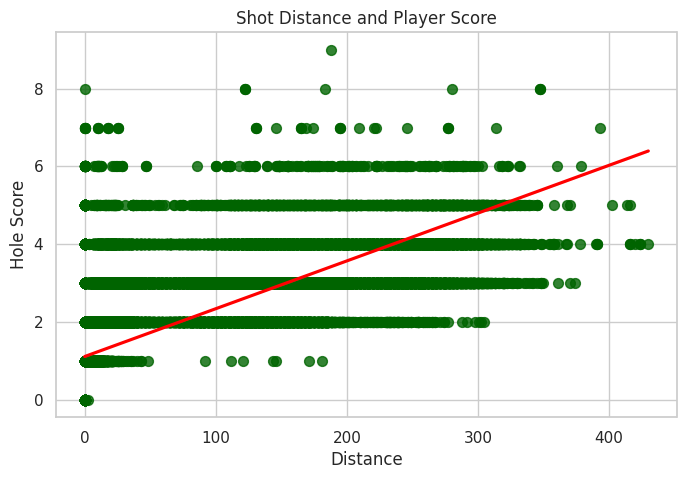

In [67]:
# Plot distance to hole and players scores

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot the data points and the linear regression line
sns.regplot(x='to_hole_yards', y='shots_to_hole', data=field_avg_df,
            scatter_kws={'s': 50, 'color': 'darkgreen'},
            line_kws={'color': 'red'})

plt.title("Shot Distance and Player Score")
plt.xlabel('Distance')
plt.ylabel('Hole Score')

plt.show()

In [68]:
# Get linear regression values
import statsmodels.api as sm

def get_benchmark(df, shot_range):
    if df.empty or len(df) < 2:
        # If there's no data to fit a line, return NaNs for this position
        return pd.DataFrame({
            'distance': shot_range,
            'benchmark': np.nan
        })

    X = sm.add_constant(df['to_hole_yards'])
    X_new = pd.DataFrame({'const': 1, 'shot_yards': shot_range})
    y = df['shots_to_hole']

    # Fit model
    model = sm.OLS(y, X).fit()

    prediction_table = pd.DataFrame({
        'distance': shot_range,
        'benchmark': model.predict(X_new)
    })

    return prediction_table

def get_position_benchmarks(df):
    """
    For every position (tee, fairway, rough, sand, approach, and putt) get the
    field average/benchmark (J) for every yard.
    """
    positions = ["tee", "fairway", "rough", "sand", "approach", "putt"]
    shot_range = np.arange(0, 601, 1)
    benchmarks = pd.DataFrame({
        'distance': shot_range
    })
    for pos in positions:
        # Get position dataframe
        shots = df[df["shot_pos"] == pos]

        # Get benchmark for every position
        benchmark = get_benchmark(shots, shot_range)

        # Rename column to have position name
        benchmark = benchmark.rename(columns={'benchmark': f'{pos}_benchmark'})

        # Merge into one dataframe
        benchmarks = benchmarks.merge(benchmark, on="distance", how="left")
    return benchmarks

benchmarks = get_position_benchmarks(field_avg_df)
print(benchmarks)

     distance  tee_benchmark  fairway_benchmark  rough_benchmark  \
0           0            NaN           1.579122         1.825731   
1           1            NaN           1.602605         1.836329   
2           2            NaN           1.626088         1.846926   
3           3            NaN           1.649571         1.857524   
4           4            NaN           1.673055         1.868122   
..        ...            ...                ...              ...   
596       596            NaN          15.575104         8.142022   
597       597            NaN          15.598587         8.152620   
598       598            NaN          15.622071         8.163218   
599       599            NaN          15.645554         8.173816   
600       600            NaN          15.669037         8.184413   

     sand_benchmark  approach_benchmark  putt_benchmark  
0          1.724735            2.090857        0.322481  
1          1.739439            2.097536        0.587341  
2        

In [69]:
benchmarks.head(20)

,distance,tee_benchmark,fairway_benchmark,rough_benchmark,sand_benchmark,approach_benchmark,putt_benchmark
0,0,NaN,1.579122,1.825731,1.724735,2.090857,0.322481
1,1,NaN,1.602605,1.836329,1.739439,2.097536,0.587341
2,2,NaN,1.626088,1.846926,1.754144,2.104214,0.852201
3,3,NaN,1.649571,1.857524,1.768848,2.110893,1.117061
4,4,NaN,1.673055,1.868122,1.783552,2.117572,1.381920
5,5,NaN,1.696538,1.878720,1.798256,2.124250,1.646780
6,6,NaN,1.720021,1.889318,1.812961,2.130929,1.911640
7,7,NaN,1.743504,1.899915,1.827665,2.137607,2.176500
8,8,NaN,1.766987,1.910513,1.842369,2.144286,2.441359
9,9,NaN,1.790471,1.921111,1.857073,2.150965,2.706219


In [70]:
benchmarks.head(101)

,distance,tee_benchmark,fairway_benchmark,rough_benchmark,sand_benchmark,approach_benchmark,putt_benchmark
0,0,NaN,1.579122,1.825731,1.724735,2.090857,0.322481
1,1,NaN,1.602605,1.836329,1.739439,2.097536,0.587341
2,2,NaN,1.626088,1.846926,1.754144,2.104214,0.852201
3,3,NaN,1.649571,1.857524,1.768848,2.110893,1.117061
4,4,NaN,1.673055,1.868122,1.783552,2.117572,1.381920
...,...,...,...,...,...,...,...
96,96,NaN,3.833508,2.843120,3.136343,2.732003,25.749018
97,97,NaN,3.856991,2.853718,3.151047,2.738682,26.013878
98,98,NaN,3.880475,2.864316,3.165751,2.745361,26.278737
99,99,NaN,3.903958,2.874913,3.180456,2.752039,26.543597


#### Putting Averages

In [71]:
# Get putts
field_avg_putts = field_avg_df[field_avg_df["shot_pos"] == "putt"]

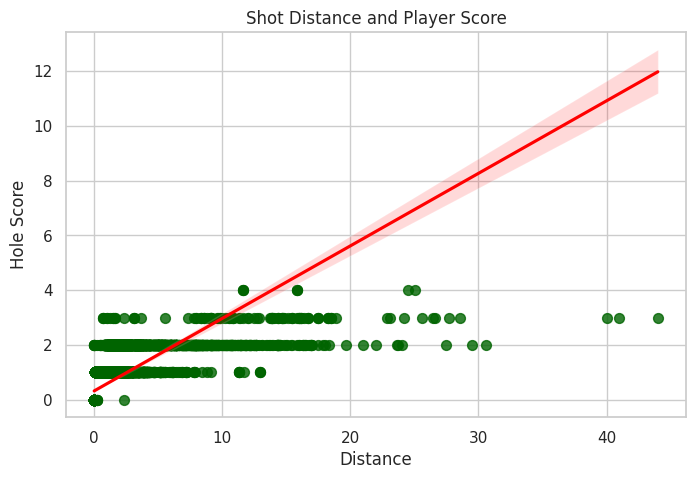

In [72]:
# Plot distance to hole putts and players scores

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot the data points and the linear regression line
sns.regplot(x='to_hole_yards', y='shots_to_hole', data=field_avg_putts,
            scatter_kws={'s': 50, 'color': 'darkgreen'},
            line_kws={'color': 'red'})

plt.title("Shot Distance and Player Score")
plt.xlabel('Distance')
plt.ylabel('Hole Score')

plt.show()

In [106]:
import math
from scipy.stats import norm

# Hole radius in yards
R_HOLE = 2.125 / 36.0

# p1 paramters
SIGMA_ALPHA = 1.46  # Angular error standard deviation
SIGMA_D = 0.057     # Distance error standard deviation
T_TARGET = 0.5      # Aim distance beyond hole in yards
H_DEPTH = 0.667     # Holeout distance threshold in yards

# p3 coefficients
A0, A1, A2, A3 = -0.106, 5.49, 0.000563, -0.00398

def get_p1(d_feet):
    """Calculates probability of one-putt using equation 5."""
    d_yards = d_feet / 3.0
    if d_yards <= 0: return 1.0

    # Angular probability
    alpha_c_deg = math.degrees(math.atan(R_HOLE / d_yards))
    prob_angle = 2 * norm.cdf(alpha_c_deg / SIGMA_ALPHA) - 1

    # Distance probability
    z_upper = (H_DEPTH - T_TARGET) / (SIGMA_D * (d_yards + T_TARGET))
    z_lower = (-T_TARGET) / (SIGMA_D * (d_yards + T_TARGET))
    prob_dist = norm.cdf(z_upper) - norm.cdf(z_lower)

    return prob_angle * prob_dist

def get_p3(d_feet):
    """
    Calculates probability three-putt using equation 6:
    1 / (1 + exp(a0 + a1*d + a2*d^2) + a3)
    """
    z = A0 + A1 * d_feet + A2 * (d_feet**2) + A3
    return 1 / (1 + math.exp(-z))

def benchmark_j(d_feet):
    """Returns the average strokes to complete the hole from distance d (equation 7)."""
    if d_feet <= 0: return 0.0
    p1 = get_p1(d_feet)
    p3 = get_p3(d_feet)
    # Combined average putts
    return p1 + 2 * (1 - p1 - p3) + 3 * p3

def compute_putt_sg(start_dist_ft, end_dist_ft=0):
    """Computes strokes gained for a single putt."""
    j_start = benchmark_j(start_dist_ft)
    j_end = benchmark_j(end_dist_ft) if end_dist_ft > 0 else 0.0
    return j_start - j_end - 1.0

# Example: A 16-foot putt that is missed and leaves a 1-inch tap-in.
# Source states J(16ft) is approx 1.8 and J(tap-in) is 1.0 [11].
sg_putt = compute_putt_sg(16, 1/12)
# sg_putt = compute_putt_sg(1, 0)
print(f"Strokes Gained: {sg_putt:.2f}")

Strokes Gained: 0.20


In [107]:
for d in [2, 10, 20, 40, 60]:
    print(d, get_p3(d))

2 0.9999810231544461
10 1.0
20 1.0
40 1.0
60 1.0


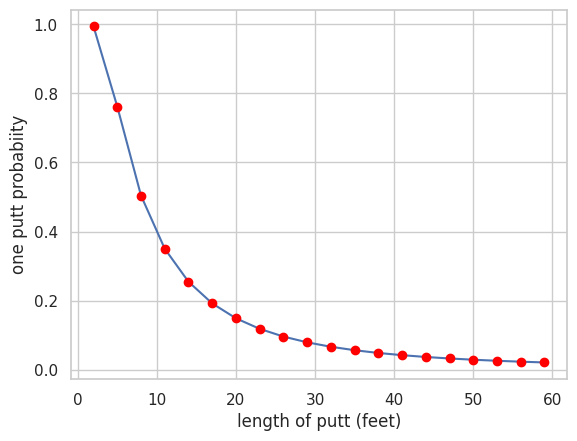

In [108]:
# Plot putt SG for 2-60 feet

# 1-putt probability

x = list(range(2, 61, 3))
y = [get_p1(i) for i in x]

plt.plot(x, y, marker='o', markerfacecolor='red',markeredgecolor='red')  # dots at each point
plt.xlabel('length of putt (feet)')
plt.ylabel('one putt probabiity')
plt.title('')
plt.show()

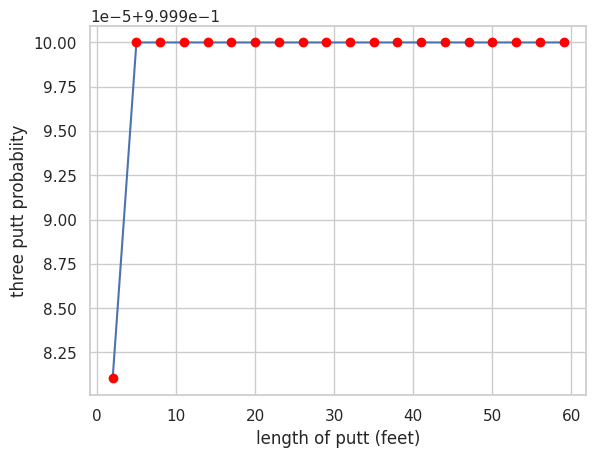

In [111]:
# 3-putt probability

x = list(range(2, 61, 3))
y = [get_p3(i) for i in x]

plt.plot(x, y, marker='o', markerfacecolor='red',markeredgecolor='red')  # dots at each point
plt.xlabel('length of putt (feet)')
plt.ylabel('three putt probabiity')
plt.title('')
plt.show()

In [112]:
# Apply putting benchmark to dataset

field_avg_putts.head()

def get_putt_benchmarks(df):
    """
    for every putt check if made in and if not set end_dist to next putts distance
    """
    # Make sure is sorted
    df = df.sort_values(by=["tournament_id", "player", "round", "hole", "shot_number"])

    # df["next_to_hole_yards"] = (
    #     df.groupby(["tournament_id", "player", "round", "hole"])["to_hole_yards"]
    #     .shift(-1)
    # )
    # # If the putt went in, distance to hole for next putt is 0
    # df["end_distance_yards"] = np.where(
    #     df["is_holed"] == True, 0.0, df["next_to_hole_yards"]
    # )
    v_evaluate_putt = np.vectorize(compute_putt_sg)

    # df["putt_benchmark"] = v_evaluate_putt(
    #     df["to_hole_yards"], df["end_distance_yards"]
    # )
    df["putt_benchmark"] = v_evaluate_putt(
        df["shot_dist_yards"], df["to_hole_yards"]
    )
    return df

putt_benchmarks = get_putt_benchmarks(field_avg_putts)
putt_benchmarks.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,...,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos,total_shots,shots_to_hole,putt_benchmark
14,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,3.0,35 ft 8 in.,4 ft 9 in.,Green,...,423,11.889,1.583,Green,False,Putt,putt,4.0,1.0,-0.319404
15,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,4.0,4 ft 9 in.,0,In Hole,...,423,1.583,0.000,Green,True,Putt,putt,4.0,0.0,1.002004
604,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,2,4.0,16 ft 0 in.,0,In Hole,...,532,5.333,0.000,Green,True,Putt,putt,4.0,0.0,1.272808
1247,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,2.0,6 ft 7 in.,2 ft 2 in.,Green,...,177,2.194,0.722,Green,False,Putt,putt,3.0,1.0,-0.969060
1248,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,3.0,2 ft 2 in.,0,In Hole,...,177,0.722,0.000,Green,True,Putt,putt,3.0,0.0,0.979285


In [113]:
putt_benchmarks.head(100)


,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,...,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos,total_shots,shots_to_hole,putt_benchmark
14,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,3.0,35 ft 8 in.,4 ft 9 in.,Green,...,423,11.889,1.583,Green,False,Putt,putt,4.0,1.0,-0.319404
15,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,4.0,4 ft 9 in.,0,In Hole,...,423,1.583,0.000,Green,True,Putt,putt,4.0,0.0,1.002004
604,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,2,4.0,16 ft 0 in.,0,In Hole,...,532,5.333,0.000,Green,True,Putt,putt,4.0,0.0,1.272808
1247,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,2.0,6 ft 7 in.,2 ft 2 in.,Green,...,177,2.194,0.722,Green,False,Putt,putt,3.0,1.0,-0.969060
1248,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,3.0,2 ft 2 in.,0,In Hole,...,177,0.722,0.000,Green,True,Putt,putt,3.0,0.0,0.979285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31388,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,4,2,4.0,4 ft 10 in.,0,In Hole,...,532,1.611,0.000,Green,True,Putt,putt,4.0,0.0,1.002219
32063,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,4,3,5.0,20 in,0,In Hole,...,177,0.556,0.000,Green,True,Putt,putt,5.0,0.0,0.949924
32524,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,4,4,4.0,6 ft 7 in.,0,In Hole,...,384,2.194,0.000,Green,True,Putt,putt,4.0,0.0,1.010225
33148,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,4,5,4.0,6 ft 3 in.,0,In Hole,...,471,2.083,0.000,Green,True,Putt,putt,4.0,0.0,1.007937


##### Plots

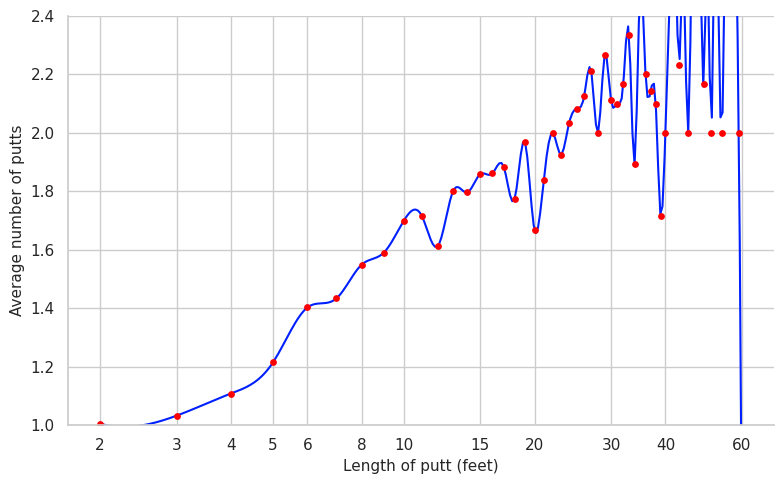

In [114]:
from scipy.interpolate import make_interp_spline

def plot_putts(df):
    # 1. Filter the raw data for only initial putts on a green
    # We want to exclude tap-ins that are part of the same sequence to avoid dragging down the baseline
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    # 2. Convert to_hole_yards to feet and round to the nearest whole foot
    putts_df['putt_dist_feet'] = np.round(putts_df['to_hole_yards'] * 3.0)

    # 3. Filter the distance boundaries to match the image layout (2 feet to 60 feet)
    putts_df = putts_df[(putts_df['putt_dist_feet'] >= 2) & (putts_df['putt_dist_feet'] <= 60)]

    # 4. Calculate the average number of shots remaining to get in the hole for each distance
    # (Using 'shots_to_hole' tracks exactly how many total putts it took from that spot)
    baseline = putts_df.groupby('putt_dist_feet')['shots_to_hole'].mean().reset_index()

    # Extract coordinates for plotting
    x = baseline['putt_dist_feet'].values
    y = baseline['shots_to_hole'].values

    # 5. Smooth out the curve using a cubic spline (just like the blue line in the image)
    x_smooth = np.logspace(np.log10(2), np.log10(60), 300) # Logarithmic spacing for smooth fit
    spline = make_interp_spline(np.log10(x), y, k=3)       # Fit spline in log-space
    y_smooth = spline(np.log10(x_smooth))

    # --- STEP 6: PLOT THE DATA ---
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot the smoothed blue trendline
    ax.plot(x_smooth, y_smooth, color='#0020ff', linewidth=1.5, zorder=1)

    # Plot the individual raw data points as red dots
    ax.scatter(x, y, color='#ff0000', s=15, zorder=2)

    # Set the X-Axis to a Logarithmic Scale to match the image spacing layout
    ax.set_xscale('log')

    # Explicitly define the custom tick labels seen in the target image
    x_ticks = [2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 60]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) for tick in x_ticks])

    # Set Y-Axis limits and ticks
    ax.set_ylim(1.0, 2.4)
    ax.set_yticks([1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])

    # Style the axes (removing top and right spines for a clean look)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=6, width=1)

    # Label the axes
    ax.set_xlabel('Length of putt (feet)', fontsize=11)
    ax.set_ylabel('Average number of putts', fontsize=11)

    plt.tight_layout()
    plt.show()

plot_putts(field_avg_df)

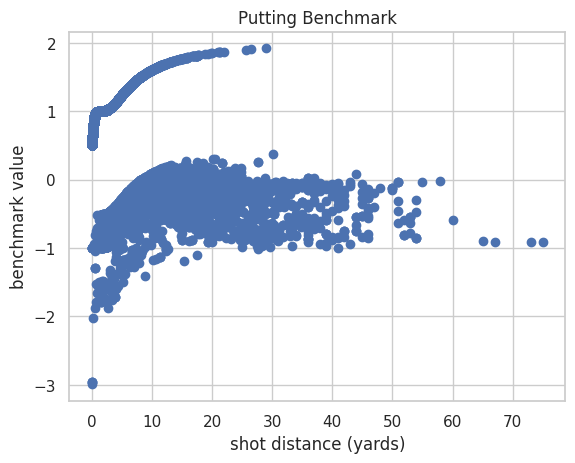

In [115]:
# Plot putts SG

x = putt_benchmarks["shot_dist_yards"]
y = putt_benchmarks["putt_benchmark"]

plt.scatter(x, y)

plt.title("Putting Benchmark")
plt.xlabel("shot distance (yards)")
plt.ylabel("benchmark value")
plt.show()

### Field Average (all data have)

In [78]:
# Get all data
field_avg_all_df = get_field_avg_df(df)
field_avg_all_df.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,par,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos,total_shots,shots_to_hole
0,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,1.0,235 yds,176 yds,Right Fairway Bunker,4,423,235.000,176.000,tee,False,Tee,approach,4.0,3.0
1,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,2.0,170 yds,30 ft 5 in.,Green,4,423,170.000,10.139,Right Fairway Bunker,False,Approach,fairway,4.0,2.0
2,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,3.0,34 ft 8 in.,3 ft 11 in.,Green,4,423,11.556,1.306,Green,False,Putt,putt,4.0,1.0
3,THE PLAYERS Championship,R2023011,Jerry Kelly,8075,1,1,4.0,3 ft 11 in.,0,In Hole,4,423,1.306,0.000,Green,True,Putt,putt,4.0,0.0
4,THE PLAYERS Championship,R2023011,Ryan Armour,19803,1,1,1.0,246 yds,166 yds,Right Rough,4,423,246.000,166.000,tee,False,Tee,approach,4.0,3.0


In [79]:
benchmarks_all_data = get_position_benchmarks(field_avg_all_df)
benchmarks_all_data.head(11)

,distance,tee_benchmark,fairway_benchmark,rough_benchmark,sand_benchmark,approach_benchmark,putt_benchmark
0,0,2.152955,1.598104,1.799078,1.689522,2.087543,0.306410
1,1,2.158937,1.619093,1.809276,1.702155,2.094234,0.610833
2,2,2.164920,1.640082,1.819475,1.714788,2.100925,0.915256
3,3,2.170902,1.661071,1.829673,1.727421,2.107616,1.219680
4,4,2.176885,1.682060,1.839872,1.740053,2.114307,1.524103
5,5,2.182867,1.703048,1.850070,1.752686,2.120998,1.828526
6,6,2.188850,1.724037,1.860269,1.765319,2.127689,2.132950
7,7,2.194832,1.745026,1.870467,1.777951,2.134380,2.437373
8,8,2.200815,1.766015,1.880666,1.790584,2.141070,2.741796
9,9,2.206797,1.787004,1.890864,1.803217,2.147761,3.046219


#### Putting

In [80]:
field_avg_putts_all = field_avg_all_df[field_avg_all_df["shot_pos"] == "putt"]

putt_benchmarks_all_data = get_putt_benchmarks(field_avg_putts_all)
putt_benchmarks_all_data.head()

,tournament,tournament_id,player,player_id,round,hole,shot_number,shot_dist,to_hole,location,...,hole_yardage,shot_dist_yards,to_hole_yards,shot_started_from,is_holed,shot_type,shot_pos,total_shots,shots_to_hole,putt_benchmark
14,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,3.0,35 ft 8 in.,4 ft 9 in.,Green,...,423,11.889,1.583,Green,False,Putt,putt,4.0,1.0,-0.319778
15,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,1,4.0,4 ft 9 in.,0,In Hole,...,423,1.583,0.000,Green,True,Putt,putt,4.0,0.0,0.002378
604,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,2,4.0,16 ft 0 in.,0,In Hole,...,532,5.333,0.000,Green,True,Putt,putt,4.0,0.0,0.272808
1247,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,2.0,6 ft 7 in.,2 ft 2 in.,Green,...,177,2.194,0.722,Green,False,Putt,putt,3.0,1.0,-1.010474
1248,THE PLAYERS Championship,R2023011,Aaron Baddeley,22371,1,3,3.0,2 ft 2 in.,0,In Hole,...,177,0.722,0.000,Green,True,Putt,putt,3.0,0.0,0.020712


#### Plots

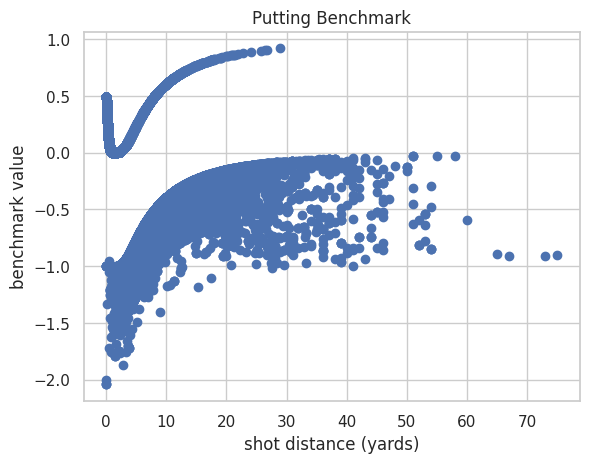

In [81]:
# Plot putts SG

x = putt_benchmarks_all_data["shot_dist_yards"]
y = putt_benchmarks_all_data["putt_benchmark"]

plt.scatter(x, y)

plt.title("Putting Benchmark")
plt.xlabel("shot distance (yards)")
plt.ylabel("benchmark value")
plt.show()

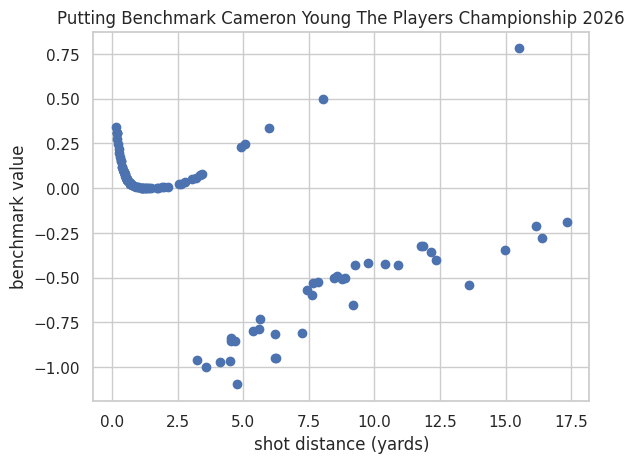

In [82]:
# Plot putts SG
cam_young_data = putt_benchmarks_all_data[
     (putt_benchmarks_all_data["tournament_id"] == "R2026011")
     & (putt_benchmarks_all_data["player"] == "Cameron Young")
]
x = cam_young_data["shot_dist_yards"]
y = cam_young_data["putt_benchmark"]

plt.scatter(x, y)

plt.title("Putting Benchmark Cameron Young The Players Championship 2026")
plt.xlabel("shot distance (yards)")
plt.ylabel("benchmark value")
plt.show()

## Markov Chain

### Bounce Back Probability

What is the probability that a player hits the green given that they missed the fairway?

$$P(GIR = 1 | DriveAccuracy = 0)$$


In [ ]:
def calculate_markov_chain_par_4_and_5(df):
    """
    Calculate markov chain for par 4 and 5.
    """
    # Sort chronologically shot-by-shot
    df_sorted = df.sort_values(
        by=["player", "round", "hole", "shot_number"]
    ).copy()
    df_par_4_and_5 = df_sorted[df_sorted['par'] != 3]

    # hole_data = get_hole_scores(df)

    # --- Tee to Fairway Probabilities ---
    # Get drives only
    drives_df = df_par_4_and_5[(df_par_4_and_5['shot_type'] == 'Tee') & (df_par_4_and_5['par'] != 3)].copy()

    # Boolean hit fairway
    drives_df['hit_fairway'] = drives_df['location'].str.lower().str.contains('fairway', na=False)

    # Since True is 1 and False is 0, mean works as the probability for True
    prob_fairway = drives_df['hit_fairway'].mean()
    prob_non_fairway = 1 - prob_fairway
    print(f"Prob of fairway from tee: {prob_fairway}")
    print(f"Prob of non-fairway from tee: {prob_non_fairway}")

    # --- Fairway to Green Probabilities ---
    df_par_4_and_5["started_in_fairway"] = df_par_4_and_5["shot_started_from"].str.lower().str.contains("fairway|green|hole|tee", na=False)

    # Aggregate to the hole level
    # For every unique hole a player plays, we determine if they hit the fairway
    # and if they successfully recorded a Green in Regulation (GIR).
    hole_summary = (
        df_par_4_and_5.groupby(["player", "round", "hole"])
        .agg(
            # Did they hit from a fairway lie at any point on this hole?
            hit_fairway=("started_in_fairway", "any"),
            # In your data, an approach shot tracking to the green is labeled as 'Green' in shot_type.
            # If the NEXT shot's starting position contains 'Green' or 'Hole', they hit the green in regulation!
            hit_green=(
                "location",
                lambda x: x.str.lower()
                .str.contains("green|hole", na=False)
                .any(),
            ),
        )
        .reset_index()
    )
    fairway_holes = hole_summary[hole_summary["hit_fairway"] == True]
    non_fairway_holes = hole_summary[hole_summary["hit_fairway"] == False]
    print(non_fairway_holes)
    prob_green_from_fairway = fairway_holes["hit_green"].mean()
    prob_green_from_non_fairway = non_fairway_holes["hit_green"].mean()
    print(f"Prob of green from fairway: {prob_green_from_fairway}")
    print(f"Prob of green from non-fairway: {prob_green_from_non_fairway}")

calculate_markov_chain_par_4_and_5(the_players_champ_df)

Prob of fairway from tee: 0.6221453738744617
Prob of non-fairway from tee: 0.37785462612553833


/tmp/ipykernel_13020/1685414683.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_par_4_and_5["started_in_fairway"] = df_par_4_and_5["shot_started_from"].str.lower().str.contains("fairway|green|hole|tee", na=False)


Empty DataFrame
Columns: [player, round, hole, hit_fairway, hit_green]
Index: []
Prob of green from fairway: 1.0
Prob of green from non-fairway: nan


In [ ]:
def calculate_markov_chain_par_3(df):
    """
    Calculate markov chain for par 3.
    """
    # Sort chronologically shot-by-shot
    df_sorted = df.sort_values(
        by=["player", "round", "hole", "shot_number"]
    ).copy()
    df_par_3 = df_sorted[df_sorted['par'] <= 3]

    # --- Tee to Green Probabilities ---
    # Get tee shots only
    tee_shots_df = df_par_3[df_par_3['shot_type'] == 'Tee'].copy()

    # Boolean hit fairway
    tee_shots_df['hit_green'] = tee_shots_df['location'].str.lower().str.contains('green|hole', na=False)

    # Since True is 1 and False is 0, mean works as the probability for True
    prob_green = tee_shots_df['hit_green'].mean()
    prob_approach = 1 - prob_green
    print(f"Prob of green from tee: {prob_green}")
    print(f"Prob of approach from tee: {prob_approach}")

    # --- Approach to Green Probabilities ---
    df_par_3["started_in_approach"] = ~df_par_3["shot_started_from"].str.lower().str.contains("fairway|green|hole|tee", na=False)

    # Aggregate to the hole level
    # For every unique hole a player plays, we determine if they hit the fairway
    # and if they successfully recorded a Green in Regulation (GIR).
    hole_summary = (
        df_par_3.groupby(["player", "round", "hole"])
        .agg(
            # Did they hit from a fairway lie at any point on this hole?
            approach_shots=("started_in_approach", "any"),
            # In your data, an approach shot tracking to the green is labeled as 'Green' in shot_type.
            # If the NEXT shot's starting position contains 'Green' or 'Hole', they hit the green in regulation!
            hit_green=(
                "location",
                lambda x: x.str.lower()
                .str.contains("green|hole", na=False)
                .any(),
            ),
        )
        .reset_index()
    )
    approach_holes = hole_summary[hole_summary["approach_shots"] == True]
    non_approach_holes = hole_summary[hole_summary["approach_shots"] == False]
    prob_green_from_approach = approach_holes["hit_green"].mean()
    prob_green_from_non_approach = non_approach_holes["hit_green"].mean()
    print(f"Prob of green from fairway: {prob_green_from_approach}")
    print(f"Prob of green from non-fairway: {prob_green_from_non_approach}")

calculate_markov_chain_par_3(the_players_champ_df)

Prob of green from tee: 0.6227298686464877
Prob of approach from tee: 0.3772701313535123


/tmp/ipykernel_13020/1219273554.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_par_3["started_in_approach"] = ~df_par_3["shot_started_from"].str.lower().str.contains("fairway|green|hole|tee", na=False)


Prob of green from fairway: 1.0
Prob of green from non-fairway: 1.0


In [ ]:
def calculate_gir_from_fairway(df):
    # 1. Sort chronologically shot-by-shot
    df_sorted = df.sort_values(
        by=["player", "round", "hole", "shot_number"]
    ).copy()

    # 2. Identify if the entry shot to the green came from a Fairway lie
    # We use .str.contains() to capture 'Left Fairway', 'Right Fairway', 'Fairway', etc.
    df_sorted["started_in_fairway"] = (
        df_sorted["shot_started_from"]
        .str.lower()
        .str.contains("fairway", na=False)
    )

    # 3. Aggregate to the hole level
    # For every unique hole a player plays, we determine if they hit the fairway
    # and if they successfully recorded a Green in Regulation (GIR).
    hole_summary = (
        df_sorted.groupby(["player", "round", "hole"])
        .agg(
            # Did they hit from a fairway lie at any point on this hole?
            hit_fairway=("started_in_fairway", "any"),
            # In your data, an approach shot tracking to the green is labeled as 'Green' in shot_type.
            # If the NEXT shot's starting position contains 'Green' or 'Hole', they hit the green in regulation!
            hit_green=(
                "location",
                lambda x: x.str.lower()
                .str.contains("green|hole", na=False)
                .any(),
            ),
        )
        .reset_index()
    )

    print(hole_summary)

    # 4. Filter down to holes where a fairway was successfully utilized
    fairway_holes = hole_summary[hole_summary["hit_fairway"] == True]

    # 5. Calculate and print the global baseline probability
    global_prob = fairway_holes["hit_green"].mean()
    print("--- GLOBAL FIELD BASELINE ---")
    print(f"P(GIR | Fairway Hit): {global_prob * 100:.2f}%\n")

    # 6. Generate individual player analytics
    player_stats = (
        fairway_holes.groupby("player")
        .agg(
            green_prob_from_fairway=("hit_green", "mean"),
            total_fairways_tracked=("hit_green", "count"),
        )
        .reset_index()
    )

    # Transform decimals to a clean percentage layout
    # player_stats["green_prob_from_fairway_%"] = (
    #     player_stats["green_prob_from_fairway"] * 100
    # ).round(2)

    # Filter out players with tiny sample sizes for cleaner data comparison
    # player_leaderboard = player_stats[player_stats["total_fairways_tracked"] >= 1]
    player_leaderboard = player_stats.sort_values(
        by="green_prob_from_fairway", ascending=False
    ).reset_index(drop=True)

    print("--- TOP APPROACH PLAYERS FROM THE FAIRWAY ---")
    return player_leaderboard[
        ["player", "green_prob_from_fairway", "total_fairways_tracked"]
    ].head(100)


# Run the updated script on your precise dataframe
calculate_gir_from_fairway(the_players_champ_df)

            player  round  hole  hit_fairway  hit_green
0       A.J. Ewart      1     1        False       True
1       A.J. Ewart      1     2         True       True
2       A.J. Ewart      1     3        False       True
3       A.J. Ewart      1     4         True       True
4       A.J. Ewart      1     5         True       True
...            ...    ...   ...          ...        ...
16267  Zecheng Dou      4    14         True       True
16268  Zecheng Dou      4    15         True       True
16269  Zecheng Dou      4    16         True       True
16270  Zecheng Dou      4    17        False       True
16271  Zecheng Dou      4    18         True       True

[16272 rows x 5 columns]
--- GLOBAL FIELD BASELINE ---
P(GIR | Fairway Hit): 100.00%

--- TOP APPROACH PLAYERS FROM THE FAIRWAY ---


,player,green_prob_from_fairway,total_fairways_tracked
0,A.J. Ewart,1.0,52
1,Aaron Baddeley,1.0,55
2,Aaron Rai,1.0,62
3,Aaron Wise,1.0,54
4,Adam Hadwin,1.0,63
...,...,...,...
95,Joe Highsmith,1.0,58
96,Joel Dahmen,1.0,63
97,Johnny Keefer,1.0,42
98,Jordan Smith,1.0,55


## Machine Learning

#### Prepare Data

In [44]:
def get_player_stats_df(df):
    # New players stats df
    player_df = (
        df[["tournament_id", "player", "player_id"]]
        .drop_duplicates()
        .sort_values(by=["tournament_id", "player"])
        .reset_index(drop=True)
    )

    # Get drives, approach, short game, putting, and in hole dist
    drive_accuracy = get_drive_accuracy_by_tour_and_player(df)
    gir = get_gir_percentage_by_tour_and_player(df)
    proximity_to_hole = get_avg_proximity_to_hole_after_approach_shot_by_tour_and_player(df)
    scrambling = get_scrambling_percentage_by_tour_and_player(df)
    sand_saves = get_player_sand_saves_by_tour_and_player(df)
    putts_per_gir = get_player_putts_per_gir_by_tour_and_player(df)
    putt_percentages = get_putt_percentages_by_tour_and_player(df)
    putt_make_percentages = get_putt_make_shot_dist_percentages_by_tour_and_player(df)
    in_hole_dist = get_avg_in_hole_shot_distance_by_tour_and_player(df)

    # Get total strokes
    total_strokes = get_total_scores(df)

    # Merge dataframes
    player_stats = (
        player_df
        .merge(drive_accuracy, on=["player", "tournament_id"], how="left")
        .merge(gir, on=["player", "tournament_id"], how="left")
        .merge(proximity_to_hole, on=["player", "tournament_id"], how="left")
        .merge(scrambling, on=["player", "tournament_id"], how="left")
        .merge(sand_saves, on=["player", "tournament_id"], how="left")
        .merge(putts_per_gir, on=["player", "tournament_id"], how="left")
        .merge(putt_percentages, on=["player", "tournament_id"], how="left")
        .merge(putt_make_percentages, on=["player", "tournament_id"], how="left")
        .merge(in_hole_dist, on=["player", "tournament_id"], how="left")
        .merge(total_strokes, on=["player", "tournament_id"], how="left")
    )
    return player_stats


# get the players championship data
# Using the players championship because have multiple years of data

# Get players championship 2021-2025
train_tour_ids = [f"R{year}011" for year in range(2021, 2026)]
train_years_only_df = df[df["tournament_id"].isin(train_tour_ids)]
# train_years_only_df = df[df["tournament_id"] == "R2024011"] # TODO switch back once have all data
test_years_only_df = df[df["tournament_id"] == "R2026011"]
# the_players_champ_df = df[df["tournament"] == "THE PLAYERS Championship"]

player_stats = get_player_stats_df(train_years_only_df)
player_stats_test = get_player_stats_df(test_years_only_df)
player_stats.head()

,tournament_id,player,player_id,driving_accuracy_%,total_drives_tracked,avg_drive_distance,GIR_%,avg_proximity_after_approach_shot_yards,approach_shots_measured,avg_proximity_after_approach_shot_feet,...,1_putt_%,2_putt_%,3_putt_%,3+_putt_%,under_5_make_%,5_to_10_make_%,over_10_make_%,avg_in_hole_shot_dist,avg_in_hole_shot_dist_feet,total_strokes
0,R2023011,Aaron Baddeley,22371,67.86,56,274.142857,61.97,2.891039,103,8.7,...,39.44,53.52,7.04,0.00,5.04,0.0,97.48,1.194458,3.58,295.0
1,R2023011,Aaron Rai,46414,78.57,56,280.910714,74.65,2.154110,91,6.5,...,42.25,50.70,4.23,2.82,8.40,0.0,97.48,3.087556,9.26,282.0
2,R2023011,Aaron Wise,49964,76.79,56,281.660714,40.28,8.417056,126,25.3,...,52.11,42.25,5.63,0.00,7.34,0.0,92.66,1.605264,4.82,308.0
3,R2023011,Adam Hadwin,33399,73.21,56,280.892857,72.22,1.651205,88,5.0,...,41.67,48.61,9.72,0.00,8.26,0.0,97.52,1.299056,3.90,281.0
4,R2023011,Adam Long,35449,66.07,56,274.964286,54.17,3.455098,112,10.4,...,38.89,48.61,12.50,0.00,9.60,0.0,96.00,1.605681,4.82,309.0


In [ ]:
# Get winners column
winners_dict = {
    "R2021011": "Justin Thomas",
    "R2022011": "Cameron Smith",
    "R2023011": "Scottie Scheffler",
    "R2024011": "Scottie Scheffler",
    "R2025011": "Rory McIlroy",
    "R2026011": "Cameron Young"
}

clean_winners = {tid: name.lower().strip() for tid, name in winners_dict.items()}

# Map and apply to train set
mapped_train = player_stats['tournament_id'].map(clean_winners)
player_stats['is_winner'] = (player_stats['player'].str.lower().str.strip() == mapped_train).astype(int)

# Map and apply to test set
mapped_test = player_stats_test['tournament_id'].map(clean_winners)
player_stats_test['is_winner'] = (player_stats_test['player'].str.lower().str.strip() == mapped_test).astype(int)

In [ ]:
print("Winners found in Train Dataset:", player_stats['is_winner'].sum())
print("Winners found in Test Dataset:", player_stats_test['is_winner'].sum())

Winners found in Train Dataset: 3
Winners found in Test Dataset: 1


In [ ]:
# Confrim winners are there
print(player_stats.groupby('tournament_id')['is_winner'].any().astype(int))
print(player_stats_test.groupby('tournament_id')['is_winner'].any().astype(int))

tournament_id
R2023011    1
R2024011    1
R2025011    1
Name: is_winner, dtype: int64
tournament_id
R2026011    1
Name: is_winner, dtype: int64


### Neural Network

Predict who will win the 2026 Player Championship given the data provided.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
player_stats.columns

Index(['tournament_id', 'player', 'player_id', 'driving_accuracy_%',
       'total_drives_tracked', 'avg_drive_distance', 'GIR_%',
       'avg_proximity_after_approach_shot_yards', 'approach_shots_measured',
       'avg_proximity_after_approach_shot_feet', 'scrambling_%',
       'scramble_opportunities', 'scramble_saves', 'sand_save_%',
       'sand_opportunities', 'sand_saves_made', 'putts_per_gir', '1_putt_%',
       '2_putt_%', '3_putt_%', '3+_putt_%', 'under_5_make_%', '5_to_10_make_%',
       'over_10_make_%', 'avg_in_hole_shot_dist', 'avg_in_hole_shot_dist_feet',
       'total_strokes', 'is_winner'],
      dtype='object')

In [ ]:
# dataset for NN

# feature_cols = ['driving_accuracy_%', 'GIR_%', 'putts_per_gir', 'total_strokes']
feature_cols = [
    'driving_accuracy_%', 'GIR_%', 'putts_per_gir', 'total_strokes',
    'under_5_make_%', '5_to_10_make_%', 'over_10_make_%',
    # '1_putt_%', '2_putt_%', '3_putt_%', '3+_putt_%',
]
# bad features: avg_driving_distance
# feature_cols = [ # all features included
#     'driving_accuracy_%',
#     'total_drives_tracked', 'avg_drive_distance', 'GIR_%',
#     'avg_proximity_after_approach_shot_yards', 'approach_shots_measured',
#     'avg_proximity_after_approach_shot_feet', 'scrambling_%',
#     'scramble_opportunities', 'scramble_saves', 'sand_save_%',
#     'sand_opportunities', 'sand_saves_made', 'putts_per_gir', '1_putt_%',
#     '2_putt_%', '3_putt_%', '3+_putt_%', 'under_5_make_%', '5_to_10_make_%',
#     'over_10_make_%', 'avg_in_hole_shot_dist', 'avg_in_hole_shot_dist_feet',
#     'total_strokes'
# ]

X_train = player_stats[feature_cols].values
y_train = player_stats['is_winner'].values.astype(np.float32)
X_test = player_stats_test[feature_cols].values
y_test = player_stats_test['is_winner'].values.astype(np.float32)

# Neural networks are highly sensitive to unscaled data (e.g., strokes vs percentages)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Convert your training and testing splits into PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Handle class imbalance: Calculate the weight of non-winners vs winners
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight = torch.tensor([num_negatives / max(num_positives, 1)])

In [ ]:
class GolfWinnerClassifier(nn.Module):
    def __init__(self, input_dim):
        super(GolfWinnerClassifier, self).__init__()

        # Layer 1: Input -> Hidden (16 neurons)
        self.fc1 = nn.Linear(input_dim, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # Layer 2: Hidden -> Hidden (8 neurons)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)

        # Layer 3: Hidden -> Output (1 raw value / logit)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [ ]:
epochs = 120
batch_size = 16
model = GolfWinnerClassifier(input_dim=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)

In [ ]:
print("--- STARTING TRAINING LOOP ---")
model.train()

for epoch in range(epochs):
    # Shuffle the dataset indices every epoch
    permutation = torch.randperm(X_train_t.size()[0])
    epoch_loss = 0

    for i in range(0, X_train_t.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[indices], y_train_t[indices]

        # 1. Clear out old gradients
        optimizer.zero_grad()

        # 2. Forward Pass (Get raw outputs / logits)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # 3. Backward Pass (Calculate gradients)
        loss.backward()

        # 4. Optimize (Update weights)
        optimizer.step()

        epoch_loss += loss.item()

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        avg_loss = epoch_loss / (X_train_t.size()[0] / batch_size)
        print(f"Epoch [{epoch+1}/{epochs}] -> Average Loss: {avg_loss:.4f}")

--- STARTING TRAINING LOOP ---
Epoch [20/120] -> Average Loss: 0.7188
Epoch [40/120] -> Average Loss: 0.2598
Epoch [60/120] -> Average Loss: 0.3183
Epoch [80/120] -> Average Loss: 0.2948
Epoch [100/120] -> Average Loss: 0.1635
Epoch [120/120] -> Average Loss: 0.2790


In [ ]:
print("\n--- RUNNING EVALUATION ON TEST DATA ---")
model.eval() # Set model to evaluation mode (turns off dropout/batchnorm updates)

with torch.no_grad():
    # 1. Get raw predictions for test features
    test_logits = model(X_test_t)

    # 2. Convert raw logits into percentages/probabilities using Sigmoid
    probabilities = torch.sigmoid(test_logits)

    # 3. Convert probabilities to hard binary decisions (1 if > 50%, else 0)
    predictions = (probabilities >= 0.5).float().numpy()

# 4. Convert the actual test targets back to a numpy array for comparison
y_true = y_test_t.numpy()

# 5. Print comprehensive performance metrics
print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_true, predictions))

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, predictions, target_names=["Non-Winner", "Winner"]))


--- RUNNING EVALUATION ON TEST DATA ---

--- CONFUSION MATRIX ---
[[116   5]
 [  0   1]]

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Non-Winner       1.00      0.96      0.98       121
      Winner       0.17      1.00      0.29         1

    accuracy                           0.96       122
   macro avg       0.58      0.98      0.63       122
weighted avg       0.99      0.96      0.97       122



In [ ]:
# --- Get winner results ---

# 1. Map probabilities array back to the original test tracker DataFrame
# (Using player_stats_test from your split step)
results_df = player_stats_test.copy()
results_df['win_probability'] = probabilities.numpy().flatten()

# 2. Sort the field to see who the model ranked at the top
ranked_field = results_df.sort_values(by='win_probability', ascending=False).reset_index(drop=True)

# 3. Print the top 5 predicted contenders
print("--- MODEL'S TOP TOURNAMENT PREDICTIONS ---")
print(ranked_field[['player', 'tournament_id', 'win_probability']].head(5))

--- MODEL'S TOP TOURNAMENT PREDICTIONS ---
              player tournament_id  win_probability
0      Cameron Young      R2026011         0.915833
1  Xander Schauffele      R2026011         0.741366
2    Tommy Fleetwood      R2026011         0.675975
3      Ludvig Ãberg      R2026011         0.615694
4        Sepp Straka      R2026011         0.544393


#### Predict Hole Scores

In [ ]:
def get_player_stats_hole_scores_df(df):
    # New players stats df
    player_df = (
        df[["tournament_id", "player", "player_id", "round", "hole"]]
        .drop_duplicates()
        .sort_values(by=["tournament_id", "player", "round", "hole"])
        .reset_index(drop=True)
    )

    # Get drives, approach, short game, putting, and in hole dist
    gir = get_gir_percentage_by_hole(df)
    putts_per_gir = get_player_putts_per_gir_by_hole(df)

    # Get total strokes
    hole_scores = get_hole_scores(df)

    # Merge dataframes
    player_stats = (
        player_df
        .merge(gir, on=["player", "tournament_id", "round", "hole"], how="left")
        .merge(putts_per_gir, on=["player", "tournament_id", "round", "hole"], how="left")
        .merge(hole_scores, on=["player", "tournament_id", "round", "hole"], how="left")
    )
    return player_stats


# get the players championship data
# Using the players championship because have multiple years of data

# Get players championship 2021-2025
train_tour_ids = [f"R{year}011" for year in range(2021, 2026)]
train_years_only_df = df[df["tournament_id"].isin(train_tour_ids)]
test_years_only_df = df[df["tournament_id"] == "R2026011"]

player_stats_hole_shots = get_player_stats_hole_scores_df(train_years_only_df)
player_stats_hole_shots_test = get_player_stats_hole_scores_df(test_years_only_df)
player_stats_hole_shots.head()

,tournament_id,player,player_id,round,hole,GIR_%,putts_per_gir,total_shots
0,R2023011,Aaron Baddeley,22371,1,1,100.0,2.0,4.0
1,R2023011,Aaron Baddeley,22371,1,2,100.0,1.0,4.0
2,R2023011,Aaron Baddeley,22371,1,3,100.0,2.0,3.0
3,R2023011,Aaron Baddeley,22371,1,4,100.0,1.0,3.0
4,R2023011,Aaron Baddeley,22371,1,5,100.0,2.0,4.0


In [ ]:
# dataset for NN

feature_cols = ['GIR_%', 'putts_per_gir']

# just cam youngs data
cam_young_df = player_stats_hole_shots[player_stats_hole_shots["player"] == "Cameron Young"]
cam_young_df_test = player_stats_hole_shots_test[player_stats_hole_shots_test["player"] == "Cameron Young"]

X_train = cam_young_df[feature_cols].values.astype(np.float32)
y_train = cam_young_df['total_shots'].values.astype(np.float32)
X_test = cam_young_df_test[feature_cols].values.astype(np.float32)
y_test = cam_young_df_test['total_shots'].values.astype(np.float32)

# Neural networks are highly sensitive to unscaled data (e.g., strokes vs percentages)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Convert your training and testing splits into PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Handle class imbalance: Calculate the weight of non-winners vs winners
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight = torch.tensor([num_negatives / max(num_positives, 1)])

In [ ]:
class GolfHolesClassifier(nn.Module):
    def __init__(self, input_dim):
        super(GolfHolesClassifier, self).__init__()

        # Layer 1: Input -> Hidden (16 neurons)
        self.fc1 = nn.Linear(input_dim, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # Layer 2: Hidden -> Hidden (8 neurons)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)

        # Layer 3: Hidden -> Output (1 raw value / logit)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [ ]:
epochs = 120
batch_size = 16
model = GolfHolesClassifier(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [ ]:
print("--- STARTING TRAINING LOOP ---")
model.train()

for epoch in range(epochs):
    # Shuffle the dataset indices every epoch
    permutation = torch.randperm(X_train_t.size()[0])
    epoch_loss = 0

    for i in range(0, X_train_t.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[indices], y_train_t[indices]

        # 1. Clear out old gradients
        optimizer.zero_grad()

        # 2. Forward Pass (Get raw outputs / logits)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # 3. Backward Pass (Calculate gradients)
        loss.backward()

        # 4. Optimize (Update weights)
        optimizer.step()

        epoch_loss += loss.item()

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        avg_loss = epoch_loss / (X_train_t.size()[0] / batch_size)
        print(f"Epoch [{epoch+1}/{epochs}] -> Average Loss: {avg_loss:.4f}")

--- STARTING TRAINING LOOP ---
Epoch [20/120] -> Average Loss: nan
Epoch [40/120] -> Average Loss: nan
Epoch [60/120] -> Average Loss: nan
Epoch [80/120] -> Average Loss: nan
Epoch [100/120] -> Average Loss: nan
Epoch [120/120] -> Average Loss: nan


In [ ]:
print("\n--- RUNNING EVALUATION ON TEST DATA ---")
model.eval() # Set model to evaluation mode (turns off dropout/batchnorm updates)

with torch.no_grad():
    predictions = model(X_test_t)

predictions = predictions.squeeze().detach().numpy()

# 4. Convert the actual test targets back to a numpy array for comparison
y_true = y_test_t.numpy()

# 5. Print comprehensive performance metrics
print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_true, predictions))

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, predictions, target_names=["Non-Winner", "Winner"]))


--- RUNNING EVALUATION ON TEST DATA ---

--- CONFUSION MATRIX ---
[[ 0  0  0  0  0  0]
 [ 6  0  0  0  0  0]
 [17  0  0  0  0  0]
 [35  0  0  0  0  0]
 [12  0  0  0  0  0]
 [ 2  0  0  0  0  0]]

--- CLASSIFICATION REPORT ---


ValueError: Number of classes, 6, does not match size of target_names, 2. Try specifying the labels parameter

In [ ]:
cam_young_df_test['predicted_shots'] = predictions

## Bayes Theorom

 $Posterior = P(\text{Winner} \mid \text{GIR %})$

$Likelihood = P(\text{GIR %} \mid \text{Winner})$

$Prior = P(\text{Winner}) = \frac{1}{number of winners} = \frac{1}{X}$

(assuming all equally likeliy to win)

In [ ]:
# Get data

# Get players championship 2021-2025
train_tour_ids = [f"R{year}011" for year in range(2021, 2026)]
train_years_only_df = df[df["tournament_id"].isin(train_tour_ids)]
# train_years_only_df = df[df["tournament_id"] == "R2024011"] # TODO switch back once have all data
test_years_only_df = df[df["tournament_id"] == "R2026011"]
# the_players_champ_df = df[df["tournament"] == "THE PLAYERS Championship"]

player_stats = get_player_stats_df(train_years_only_df)
player_stats_test = get_player_stats_df(test_years_only_df)

# Get winners column
winners_dict = {
    "R2021011": "Justin Thomas",
    "R2022011": "Cameron Smith",
    "R2023011": "Scottie Scheffler",
    "R2024011": "Scottie Scheffler",
    "R2025011": "Rory McIlroy",
    "R2026011": "Cameron Young"
}

clean_winners = {tid: name.lower().strip() for tid, name in winners_dict.items()}

# Map and apply to train set
mapped_train = player_stats['tournament_id'].map(clean_winners)
player_stats['is_winner'] = (player_stats['player'].str.lower().str.strip() == mapped_train).astype(int)

# Map and apply to test set
mapped_test = player_stats_test['tournament_id'].map(clean_winners)
player_stats_test['is_winner'] = (player_stats_test['player'].str.lower().str.strip() == mapped_test).astype(int)

In [ ]:
# Get likelihood of a bernuli dist
def get_likelihood(thetas, x):
    num_winners = len(np.where(x == 1)[0])
    num_nonwinners = len(np.where(x == 0)[0])
    like = np.power(thetas, num_nonwinners)*np.power((1-thetas), num_winners)
    return like

# Get true winner of 2026
def get_true_winner(x):
    winner = x[x["is_winner"] == 1]["GIR_%"].to_numpy()
    nonwinner = x[x["is_winner"] == 0]["GIR_%"].to_numpy()
    true_winner = winner[-1]
    print(f"True winner: {true_winner}")
    return true_winner


true_winner = get_true_winner(player_stats)

# Get data
x = player_stats["is_winner"].to_numpy()
thetas = player_stats["GIR_%"].to_numpy()

likelihood = get_likelihood(thetas, x)
print(likelihood)

True winner: 63.38
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -i

/tmp/ipykernel_13020/3054368806.py:5: RuntimeWarning: overflow encountered in power
  like = np.power(thetas, num_nonwinners)*np.power((1-thetas), num_winners)


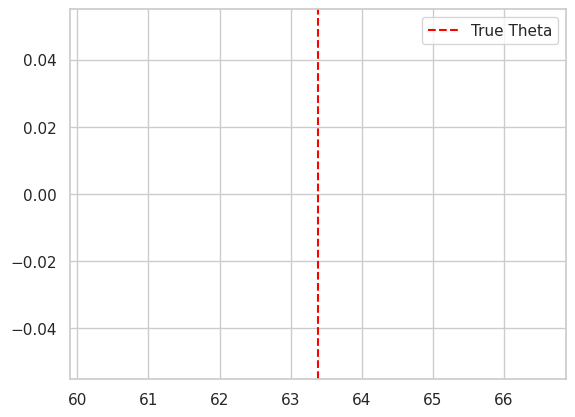

In [ ]:
plt.plot(thetas, likelihood)
plt.axvline(true_winner, linestyle='--', c='red', label='True Theta')
plt.legend()
plt.show()

## KNN

In [ ]:
from collections import Counter

def euclidean_distance(x1, x2):
    distance = np.sqrt(np.sum((x1-x2)**2))
    return distance

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        # compute the distance
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # get the closest k
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # print("Neighbor indices:", k_indices)
        # print("Neighbor labels:", k_nearest_labels)

        # # majority vote (Classification)
        # most_common = Counter(k_nearest_labels).most_common()
        # return most_common[0][0]

        # Regression
        return np.mean(k_nearest_labels)

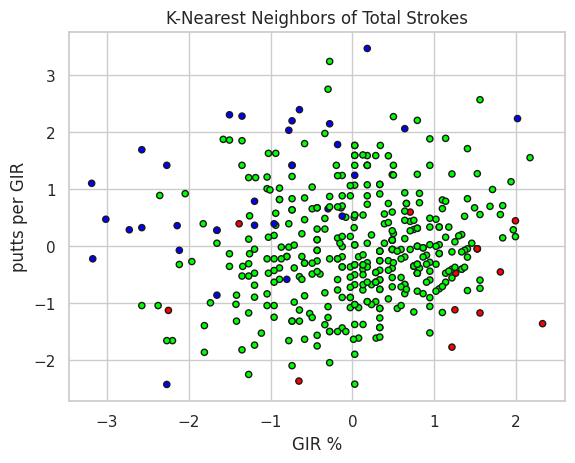

In [ ]:
# Get Data

from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

feature_cols = ['GIR_%', 'putts_per_gir']

X_train = player_stats[feature_cols].values.astype(np.float32)
y_train = player_stats['total_strokes'].values.astype(np.float32)
X_test = player_stats_test[feature_cols].values.astype(np.float32)
y_test = player_stats_test['total_strokes'].values.astype(np.float32)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Neural networks are highly sensitive to unscaled data (e.g., strokes vs percentages)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Plot data

plt.figure()
plt.scatter(X_train[:,0],X_train[:,1], c=y_train, cmap=cmap, edgecolor='k', s=20)
plt.title("K-Nearest Neighbors of Total Strokes")
plt.xlabel("GIR %")
plt.ylabel("putts per GIR")
plt.show()

In [ ]:
# Train

clf = KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

print(predictions)

acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

Neighbor indices: [268  39 298  86 330]
Neighbor labels: [np.float32(300.0), np.float32(309.0), np.float32(300.0), np.float32(336.0), np.float32(309.0)]
Neighbor indices: [112 220  54 161  60]
Neighbor labels: [np.float32(299.0), np.float32(294.0), np.float32(301.0), np.float32(302.0), np.float32(305.0)]
Neighbor indices: [ 91 183  52 413 422]
Neighbor labels: [np.float32(299.0), np.float32(296.0), np.float32(297.0), np.float32(287.0), np.float32(294.0)]
Neighbor indices: [ 77   7 312 172  11]
Neighbor labels: [np.float32(280.0), np.float32(281.0), np.float32(294.0), np.float32(301.0), np.float32(295.0)]
Neighbor indices: [ 12 261 400 241 356]
Neighbor labels: [np.float32(284.0), np.float32(279.0), np.float32(290.0), np.float32(291.0), np.float32(287.0)]
Neighbor indices: [361 423 136 130 105]
Neighbor labels: [np.float32(296.0), np.float32(301.0), np.float32(304.0), np.float32(326.0), np.float32(312.0)]
Neighbor indices: [421 295 367 111  67]
Neighbor labels: [np.float32(289.0), np.fl

In [ ]:
knn_results = player_stats_test[['player']].copy()
knn_results['actual_strokes'] = y_test
knn_results['predicted_strokes'] = predictions
knn_results = knn_results.sort_values(by="predicted_strokes")
knn_results.head()

,player,actual_strokes,predicted_strokes
93,Ryo Hisatsune,282.0,275.600006
119,Xander Schauffele,277.0,278.399994
82,Patrick Rodgers,281.0,280.200012
97,Sam Stevens,291.0,280.200012
17,Cameron Young,275.0,280.399994


### Predict Hole Scores

In [ ]:
GROUP_BY_HOLES = ['tournament_id', 'round', 'hole', 'player']

def get_gir_by_hole(df):
    green_shots = df[df['location'].str.lower().str.contains('green', na=False)].copy()

    # Find the first shot that hit the green for every player on every hole
    # (Using groupby + min ensures we catch the exact shot number they reached the surface)
    first_green_shot = green_shots.groupby(['tournament_id', 'round', 'hole', 'player', 'par'])['shot_number'].min().reset_index()
    first_green_shot.rename(columns={'shot_number': 'shot_reached_green'}, inplace=True)

    # Apply the official GIR condition: shot_reached_green <= (par - 2)
    first_green_shot['GIR'] = first_green_shot['shot_reached_green'] <= (first_green_shot['par'] - 2)

    # return first_green_shot[['player', 'par', 'shot_reached_green', 'GIR']]
    return first_green_shot

def get_gir_percentage_by_hole(df):
    gir = get_gir_by_hole(df)

    # Calculate final GIR %
    player_gir_df = gir.groupby(GROUP_BY_HOLES)['GIR'].mean().reset_index()

    # Get the percentage
    player_gir_df['GIR_%'] = (player_gir_df['GIR'] * 100).round(2)
    player_gir_df = player_gir_df.sort_values(by='GIR_%', ascending=False).reset_index(drop=True)

    # Clean up temporary aggregation column
    player_gir_df.drop(columns=['GIR'], inplace=True)
    return player_gir_df

def get_player_putts_per_gir_by_hole(df):
    # Get putts
    putts_df = df[df['shot_type'] == 'Putt'].copy()

    # Group by player and round to count their total putts
    round_putts = putts_df.groupby(GROUP_BY_HOLES).size().reset_index(name="total_putts")

    # Get average putts per round
    player_putts_per_round = round_putts.groupby(GROUP_BY_HOLES)["total_putts"].mean().reset_index(name="putts_per_round")
    player_putts_per_round["putts_per_round"] = player_putts_per_round["putts_per_round"].round(2)

    # Get Putts per GIR

    # Count the number of putts taken on every hole
    hole_putts = putts_df.groupby(GROUP_BY_HOLES).size().reset_index(name='hole_putt_count')

    # Get 'GIR' boolean column (True/False)
    gir_df = get_gir_by_hole(df)
    gir_putts_base = pd.merge(
        gir_df[['tournament_id', 'round', 'hole', 'player', 'GIR']],
        hole_putts,
        on=GROUP_BY_HOLES,
        how='left'
    )

    # Fill NaN with 0 for holes where they holed out from off the green and took 0 putts
    gir_putts_base['hole_putt_count'] = gir_putts_base['hole_putt_count'].fillna(0)

    # Isolate only the holes where the player successfully made a GIR
    gir_only_holes = gir_putts_base[gir_putts_base['GIR'] == True]

    # Calculate the final average putts per GIR
    # player_putts_per_gir = gir_only_holes.groupby(['tournament_id', 'player']).size().reset_index(name='putts_per_gir') # total counts
    return gir_only_holes.groupby(GROUP_BY_HOLES)['hole_putt_count'].mean().reset_index(name='putts_per_gir') # average


In [ ]:
def get_player_stats_hole_scores_df(df):
    # New players stats df
    player_df = (
        df[["tournament_id", "player", "player_id", "round", "hole"]]
        .drop_duplicates()
        .sort_values(by=["tournament_id", "player", "round", "hole"])
        .reset_index(drop=True)
    )

    # Get drives, approach, short game, putting, and in hole dist
    gir = get_gir_percentage_by_hole(df)
    putts_per_gir = get_player_putts_per_gir_by_hole(df)

    # Get total strokes
    hole_scores = get_hole_scores(df)

    # Merge dataframes
    player_stats = (
        player_df
        .merge(gir, on=["player", "tournament_id", "round", "hole"], how="left")
        .merge(putts_per_gir, on=["player", "tournament_id", "round", "hole"], how="left")
        .merge(hole_scores, on=["player", "tournament_id", "round", "hole"], how="left")
    )
    return player_stats


# get the players championship data
# Using the players championship because have multiple years of data

# Get players championship 2021-2025
train_tour_ids = [f"R{year}011" for year in range(2021, 2026)]
train_years_only_df = df[df["tournament_id"].isin(train_tour_ids)]
test_years_only_df = df[df["tournament_id"] == "R2026011"]

player_stats_hole_shots = get_player_stats_hole_scores_df(train_years_only_df)
player_stats_hole_shots_test = get_player_stats_hole_scores_df(test_years_only_df)
player_stats_hole_shots.head()

,tournament_id,player,player_id,round,hole,GIR_%,putts_per_gir,total_shots
0,R2023011,Aaron Baddeley,22371,1,1,100.0,2.0,4.0
1,R2023011,Aaron Baddeley,22371,1,2,100.0,1.0,4.0
2,R2023011,Aaron Baddeley,22371,1,3,100.0,2.0,3.0
3,R2023011,Aaron Baddeley,22371,1,4,100.0,1.0,3.0
4,R2023011,Aaron Baddeley,22371,1,5,100.0,2.0,4.0


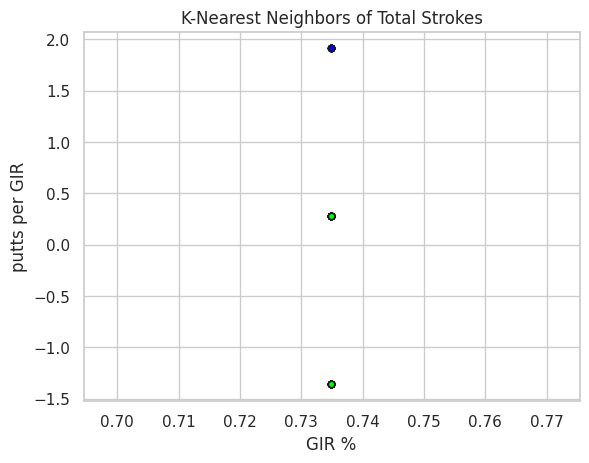

In [ ]:
# Get Data

from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

feature_cols = ['GIR_%', 'putts_per_gir']

# just cam youngs data
cam_young_df = player_stats_hole_shots[player_stats_hole_shots["player"] == "Cameron Young"]
cam_young_df_test = player_stats_hole_shots_test[player_stats_hole_shots_test["player"] == "Cameron Young"]

X_train = cam_young_df[feature_cols].values.astype(np.float32)
y_train = cam_young_df['total_shots'].values.astype(np.float32)
X_test = cam_young_df_test[feature_cols].values.astype(np.float32)
y_test = cam_young_df_test['total_shots'].values.astype(np.float32)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Neural networks are highly sensitive to unscaled data (e.g., strokes vs percentages)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Plot data

plt.figure()
plt.scatter(X_train[:,0],X_train[:,1], c=y_train, cmap=cmap, edgecolor='k', s=20)
plt.title("K-Nearest Neighbors of Total Strokes")
plt.xlabel("GIR %")
plt.ylabel("putts per GIR")
plt.show()

In [ ]:
# Train
clf = KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

print(predictions)

acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

[np.float32(3.8), np.float32(3.2), np.float32(3.8), np.float32(3.2), np.float32(3.8), np.float32(4.0), np.float32(3.8), np.float32(4.0), np.float32(3.2), np.float32(3.8), np.float32(3.8), np.float32(3.8), np.float32(3.8), np.float32(4.0), np.float32(4.0), np.float32(3.8), np.float32(3.8), np.float32(3.2), np.float32(3.8), np.float32(3.8), np.float32(3.8), np.float32(3.8), np.float32(4.0), np.float32(4.0), np.float32(3.8), np.float32(3.2), np.float32(4.0), np.float32(3.8), np.float32(4.0), np.float32(3.8), np.float32(3.8), np.float32(3.2), np.float32(3.2), np.float32(4.0), np.float32(3.2), np.float32(4.0), np.float32(3.8), np.float32(4.0), np.float32(4.0), np.float32(4.0), np.float32(3.8), np.float32(3.2), np.float32(3.8), np.float32(4.0), np.float32(3.8), np.float32(3.8), np.float32(3.2), np.float32(3.8), np.float32(3.2), np.float32(4.0), np.float32(3.8), np.float32(3.8), np.float32(3.2), np.float32(4.0), np.float32(3.2), np.float32(3.8), np.float32(4.0), np.float32(3.8), np.float32(3.

In [ ]:
knn_results = cam_young_df_test[['player']].copy()
knn_results['actual_shots'] = y_test
knn_results['predicted_shots'] = predictions
knn_results['predicted_shots'] = knn_results['predicted_shots'].round(0)
knn_results = knn_results.sort_values(by="predicted_shots")
knn_results.head()

,player,actual_shots,predicted_shots
1224,Cameron Young,4.0,3.0
1226,Cameron Young,3.0,3.0
1231,Cameron Young,4.0,3.0
1240,Cameron Young,3.0,3.0
1248,Cameron Young,2.0,3.0


In [ ]:
avg_abs_error = (knn_results['actual_shots'] - knn_results['predicted_shots']).abs().mean()
print(avg_abs_error)

0.45833334
